In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

import yaml
try:
    with open("../config.yaml", "r") as file:
        cfg=yaml.safe_load(file)
except:
    print("Yaml configuration file not found!")

In [2]:
# set color and style for graphs

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#0f1117',
    'axes.edgecolor':   '#333333',
    'axes.labelcolor':  '#cccccc',
    'xtick.color':      '#cccccc',
    'ytick.color':      '#cccccc',
    'text.color':       '#ffffff',
    'grid.color':       '#222222',
    'grid.linewidth':   0.5,
    'legend.facecolor': '#1a1a2e',
    'legend.edgecolor': '#333333',
    'font.family':      'DejaVu Sans'})

TICKER_COLORS = {
    'NVDA': '#76b900',  
    'AMD':  '#ed1c24',  
    'INTC': '#0071c5',  
    'AVGO': '#ff6f00',  
    'QCOM': '#9c27b0', 
    'TXN':  '#00897b',  
    'MU':   '#00bcd4',  
    'ADI':  '#f06292', 
    'NXPI': '#fdd835',
    'MRVL': '#8d6e63'}

def billions(x, _): return f'${x/1e9:.0f}B'

from pathlib import Path
GRAPH_DIR = Path("../data/graphs")
GRAPH_DIR.mkdir(parents=True, exist_ok=True)
def save(fig, name, dpi=300):fig.savefig(
        GRAPH_DIR / f"{name}.png",
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white")

# 1. Data overview

In [3]:
df = pd.read_csv(cfg['clean']['semiconductor_quarterly'])
display(df.head())
display(df.columns)

,ticker,company,quarter_end,fiscal_quarter_label,revenue_q,gross_profit_q,ebit_q,net_income_q,rd_expense_q,operating_cf_q,...,rd_to_revenue,capex_to_revenue,debt_to_ebitda,revenue_growth_yoy,ebitda_growth_yoy,net_income_growth_yoy,enterprise_value,pe_ratio,ev_to_ebitda,price_to_sales
0,ADI,Analog Devices Inc.,2022-01-29,2022Q1,2684293000,1401997000,364757000,280077000,426780000,856413000,...,0.169912,0.045881,0.000000,0.722403,0.404914,-0.279116,7.539321e+10,60.206564,24.831528,9.140515
1,ADI,Analog Devices Inc.,2022-04-30,2022Q2,2972064000,1944520000,918161000,783273000,420901000,1221807000,...,0.159247,0.045827,0.000000,0.788884,1.081566,0.852125,7.345487e+10,45.783600,19.266351,7.708284
2,ADI,Analog Devices Inc.,2022-07-30,2022Q3,3109880000,2043142000,893306000,748985000,431829000,1247846000,...,0.151149,0.047324,0.000000,0.768130,0.827104,0.488116,8.455400e+10,45.592140,18.877551,7.750808
3,ADI,Analog Devices Inc.,2022-10-29,2022Q4,3247716000,2142815000,1102476000,936226000,421008000,1149336000,...,0.141545,0.058208,1.174389,0.388169,1.898240,11.369707,7.509189e+10,25.472908,13.466502,5.827711
4,ADI,Analog Devices Inc.,2023-01-28,2023Q1,3249630000,2124341000,1130820000,961474000,414095000,1406305000,...,0.134176,0.060761,1.004266,0.210609,0.838625,2.432892,8.635316e+10,23.801031,13.577647,6.489757


Index(['ticker', 'company', 'quarter_end', 'fiscal_quarter_label', 'revenue_q',
       'gross_profit_q', 'ebit_q', 'net_income_q', 'rd_expense_q',
       'operating_cf_q', 'capex_q', 'cash_q', 'total_equity_q', 'total_debt_q',
       'da_q', 'ebitda_q', 'close_price', 'shares_outstanding', 'market_cap',
       'free_cash_flow_q', 'revenue_ttm', 'gross_profit_ttm', 'ebit_ttm',
       'net_income_ttm', 'rd_ttm', 'capex_ttm', 'operating_cf_ttm',
       'free_cash_flow_ttm', 'ebitda_ttm', 'gross_margin', 'operating_margin',
       'ebitda_margin', 'net_margin', 'avg_equity_ttm', 'roe', 'rd_to_revenue',
       'capex_to_revenue', 'debt_to_ebitda', 'revenue_growth_yoy',
       'ebitda_growth_yoy', 'net_income_growth_yoy', 'enterprise_value',
       'pe_ratio', 'ev_to_ebitda', 'price_to_sales'],
      dtype='str')

In [4]:
df['quarter_end'] = pd.to_datetime(df['quarter_end'])
df = df.sort_values(['ticker', 'quarter_end']).reset_index(drop=True)

tickers = sorted(df['ticker'].unique())
palette  = [TICKER_COLORS[t] for t in tickers]
n_tickers = len(tickers)

print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} cols | {n_tickers} companies | "
      f"{df['quarter_end'].min().date()} → {df['quarter_end'].max().date()}")

Dataset: 175 rows × 45 cols | 10 companies | 2022-01-29 → 2026-05-28


In [5]:
print("DESCRIPTIVE STATS (key columns)")
key_cols = ['market_cap','enterprise_value','revenue_ttm','ebitda_ttm',
            'net_income_ttm','free_cash_flow_ttm','gross_margin',
            'operating_margin','ebitda_margin','net_margin',
            'revenue_growth_yoy','pe_ratio','ev_to_ebitda','price_to_sales']
display(df[key_cols].describe().round(2).to_string())

DESCRIPTIVE STATS (key columns)


'         market_cap  enterprise_value   revenue_ttm    ebitda_ttm  net_income_ttm  free_cash_flow_ttm  gross_margin  operating_margin  ebitda_margin  net_margin  revenue_growth_yoy  pe_ratio  ev_to_ebitda  price_to_sales\ncount  1.750000e+02      1.750000e+02  1.750000e+02  1.750000e+02    1.750000e+02        1.750000e+02        175.00            175.00         175.00      175.00              171.00    175.00        175.00          175.00\nmean   3.456074e+11      3.570621e+11  3.451462e+10  1.394459e+10    9.311490e+09        7.811515e+09          0.53              0.22           0.35        0.19                0.23    -19.43         20.50            7.35\nstd    8.384164e+11      8.381704e+11  3.540198e+10  2.236401e+10    2.101724e+10        1.779566e+10          0.14              0.21           0.15        0.20                0.53    571.79         78.48            6.09\nmin    1.809408e+10      3.561939e+10  4.462400e+09 -2.990000e+08   -2.050400e+10       -1.989600e+10         -

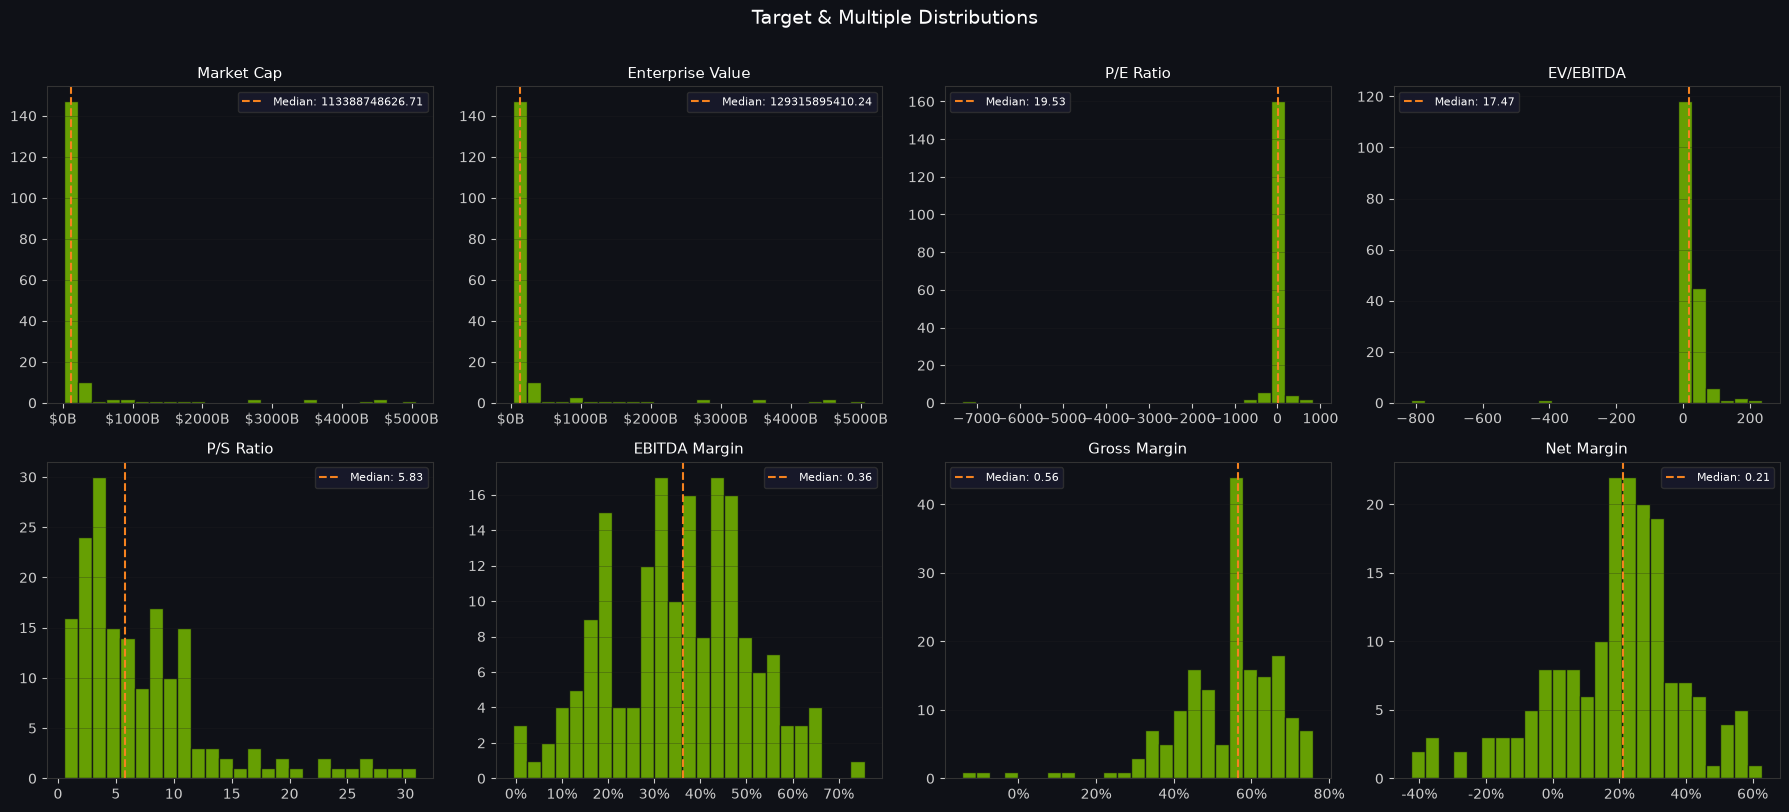

In [6]:
# distribution of target variables 
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Target & Multiple Distributions', fontsize=14, y=1.01)
targets = [
    ('market_cap',      'Market Cap',      billions),
    ('enterprise_value','Enterprise Value', billions),
    ('pe_ratio',        'P/E Ratio',        None),
    ('ev_to_ebitda',    'EV/EBITDA',        None),
    ('price_to_sales',  'P/S Ratio',        None),
    ('ebitda_margin',   'EBITDA Margin',    lambda x,_: f'{x:.0%}'),
    ('gross_margin',    'Gross Margin',     lambda x,_: f'{x:.0%}'),
    ('net_margin',      'Net Margin',       lambda x,_: f'{x:.0%}'),]

for ax, (col, label, fmt) in zip(axes.flat, targets):
    data = df[col].dropna()
    ax.hist(data, bins=25, color='#76b900', edgecolor='#0f1117', alpha=0.85)
    ax.axvline(data.median(), color='#f5821f', lw=1.5, ls='--', label=f'Median: {data.median():.2f}')
    ax.set_title(label, fontsize=11)
    if fmt: ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt))
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
save(fig, '01_distributions')
plt.show()

The distribution of valuation multiples is right-skewed because of NVDA and AMD outliers. Median EV/EBITDA is at 17x but the mean is pulled to 20x, and P/E hits extremes of -7337 (INTC loss quarters), so rank-based statistics will be more reliable than means throughout this analysis.

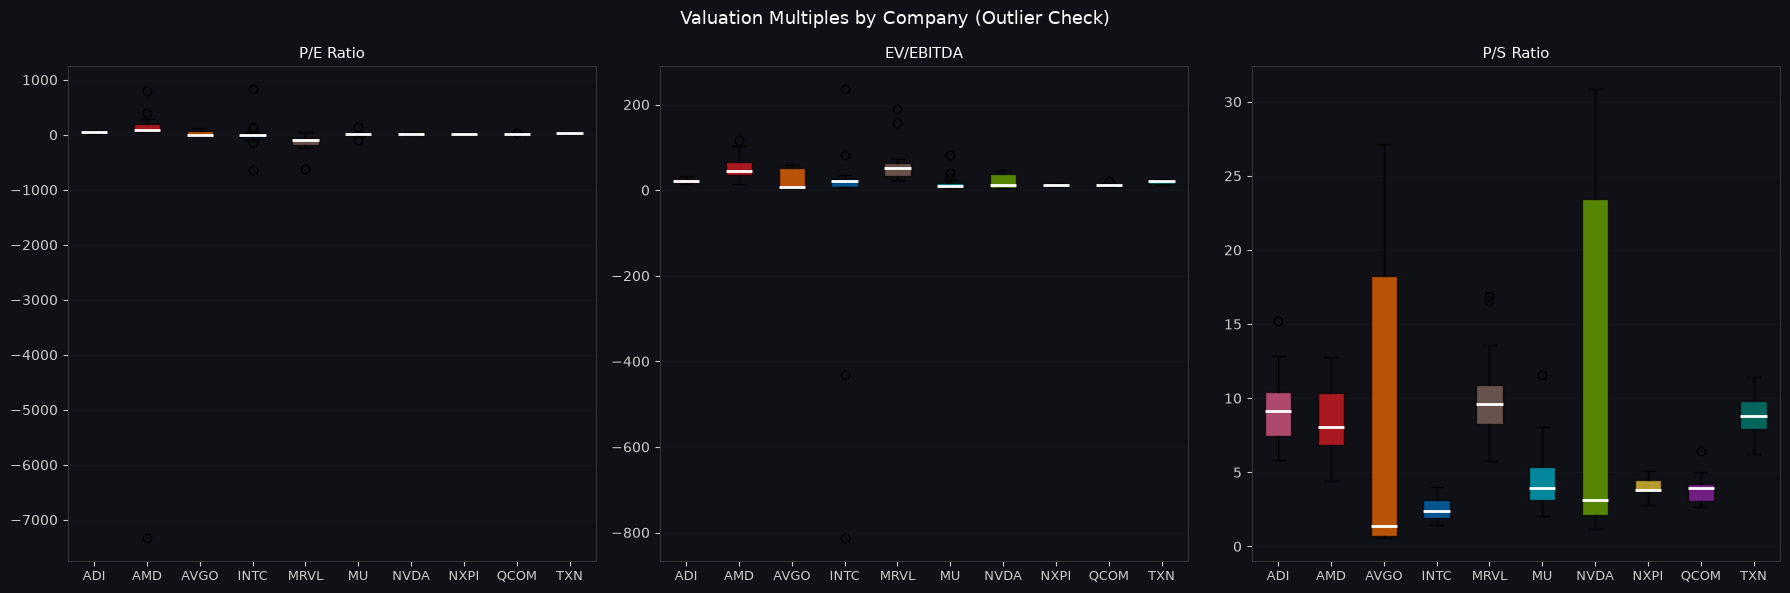

In [7]:
# Outlier boxplots (valuation multiples by ticker)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Valuation Multiples by Company (Outlier Check)', fontsize=13)
multiples = [('pe_ratio','P/E Ratio'), ('ev_to_ebitda','EV/EBITDA'), ('price_to_sales','P/S Ratio')]
for ax, (col, label) in zip(axes, multiples):
    data_by_ticker = [df[df['ticker']==t][col].dropna().values for t in tickers]
    bp = ax.boxplot(data_by_ticker, patch_artist=True, medianprops=dict(color='white', lw=2))
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels(tickers, fontsize=9)
    ax.set_title(label, fontsize=11)
    ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
save(fig, '02_outlier_boxplots')
plt.show()

# 2. Market Value and Stock Price evolution

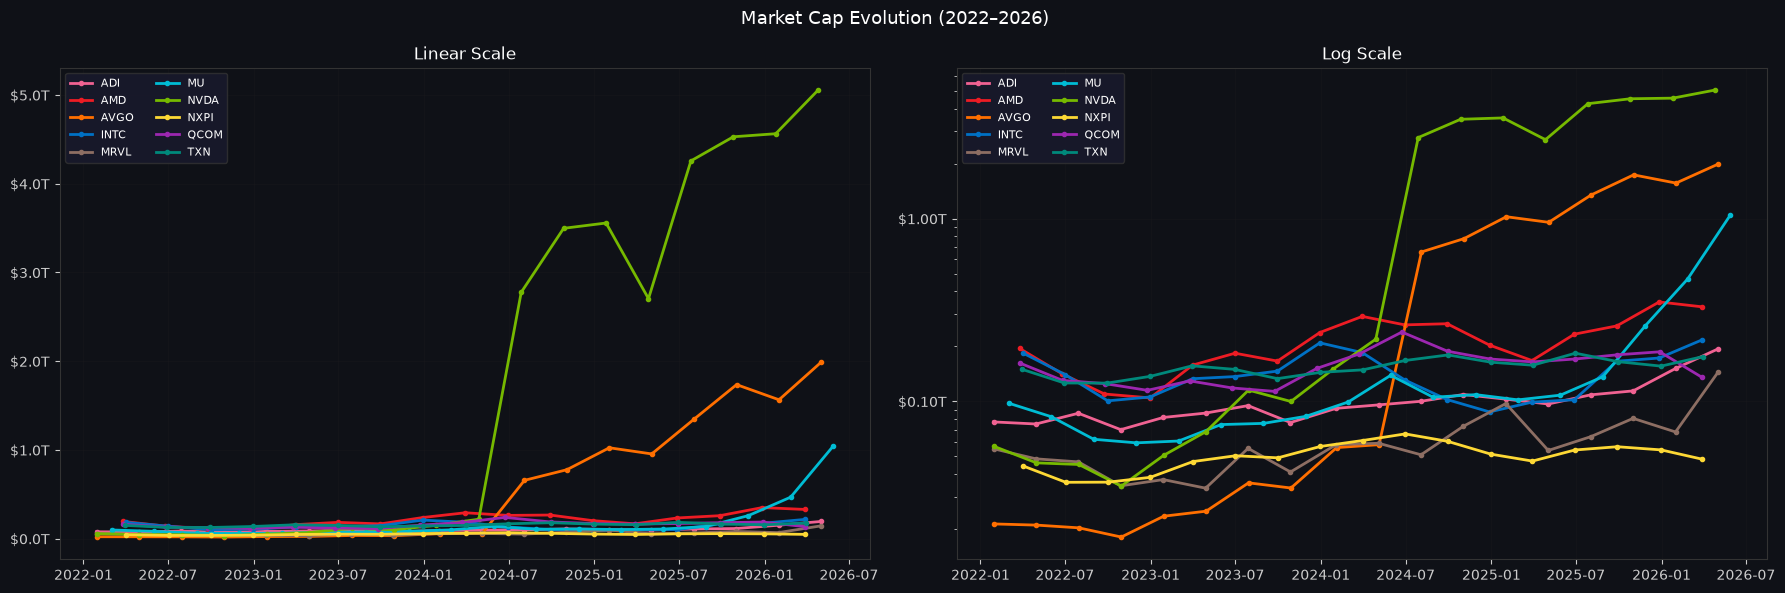

In [8]:
# Market Cap over time
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Market Cap Evolution (2022–2026)', fontsize=13)

for t in tickers:
    sub = df[df['ticker'] == t]
    for ax in axes:
        ax.plot(sub['quarter_end'], sub['market_cap'] / 1e12,
                color=TICKER_COLORS[t], lw=2, marker='o', ms=3, label=t)

axes[0].set_title('Linear Scale')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.1f}T'))
axes[1].set_yscale('log')
axes[1].set_title('Log Scale')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.2f}T'))

for ax in axes:
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_xlabel('')

plt.tight_layout()
save(fig, '03_market_cap_over_time')
plt.show()

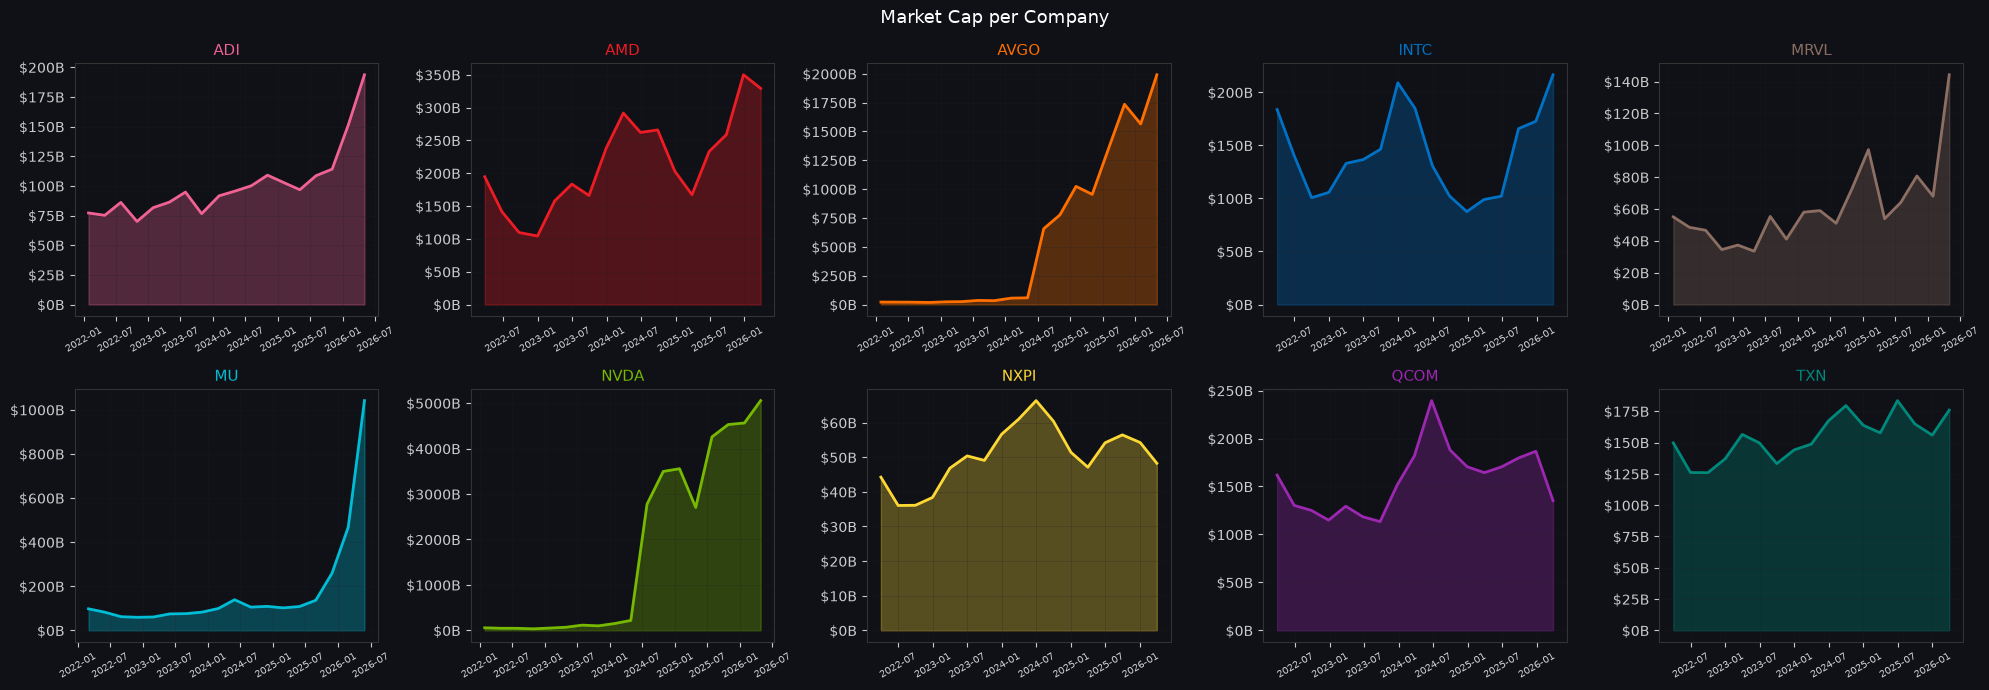

In [9]:
# Market Cap per company
fig, axes = plt.subplots(2, 5, figsize=(20, 7), sharey=False)
fig.suptitle('Market Cap per Company', fontsize=13)
for ax, t in zip(axes.flat, tickers):
    sub = df[df['ticker'] == t]
    ax.fill_between(sub['quarter_end'], sub['market_cap']/1e9,
                    alpha=0.3, color=TICKER_COLORS[t])
    ax.plot(sub['quarter_end'], sub['market_cap']/1e9,
            color=TICKER_COLORS[t], lw=2)
    ax.set_title(t, fontsize=11, color=TICKER_COLORS[t])
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}B'))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.grid(alpha=0.3)
plt.tight_layout()
save(fig, '04_market_cap_faceted')
plt.show()

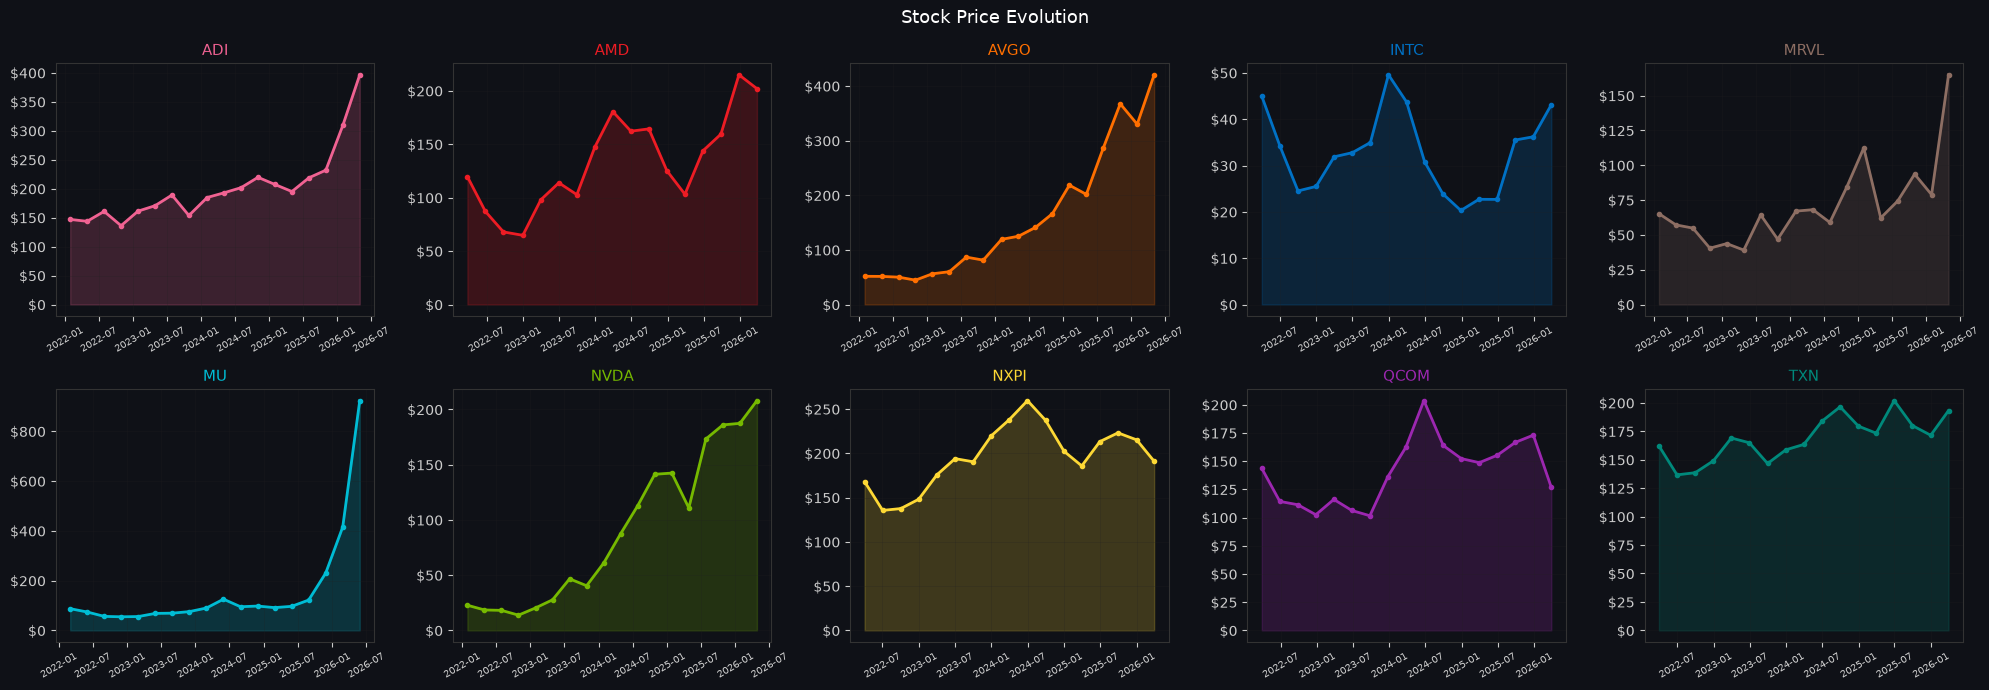

In [10]:
# Stock price over time 
fig, axes = plt.subplots(2, 5, figsize=(20, 7), sharey=False)
fig.suptitle('Stock Price Evolution', fontsize=13)
for ax, t in zip(axes.flat, tickers):
    sub = df[df['ticker'] == t]
    ax.plot(sub['quarter_end'], sub['close_price'],
            color=TICKER_COLORS[t], lw=2, marker='o', ms=3)
    ax.fill_between(sub['quarter_end'], sub['close_price'],
                    alpha=0.2, color=TICKER_COLORS[t])
    ax.set_title(t, fontsize=11, color=TICKER_COLORS[t])
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}'))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.grid(alpha=0.3)
plt.tight_layout()
save(fig, '05_stock_price_faceted')
plt.show()

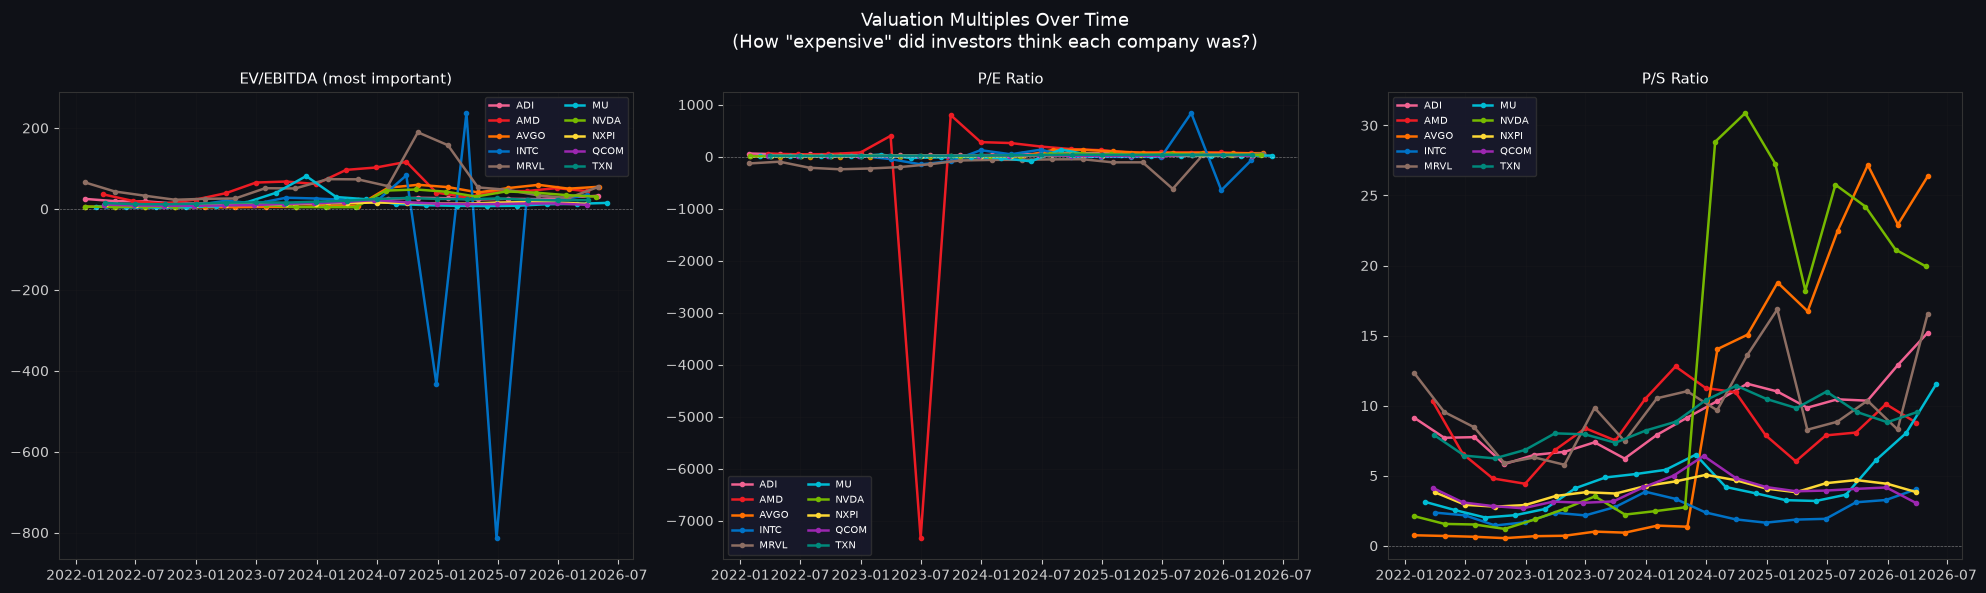

In [11]:
# Valuation multiples over time
multiples_ts = [
    ('ev_to_ebitda',  'EV/EBITDA (most important)'),
    ('pe_ratio',      'P/E Ratio'),
    ('price_to_sales','P/S Ratio')]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Valuation Multiples Over Time\n(How "expensive" did investors think each company was?)', fontsize=13)
for ax, (col, label) in zip(axes, multiples_ts):
    for t in tickers:
        sub = df[df['ticker'] == t]
        ax.plot(sub['quarter_end'], sub[col],
                color=TICKER_COLORS[t], lw=1.8, marker='o', ms=3, label=t)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)
    ax.axhline(0, color='white', lw=0.5, ls='--', alpha=0.4)
plt.tight_layout()
save(fig, '06_valuation_multiples_time')
plt.show()

NVDA's market cap grew from $34 billion to a peak of $5T, this is a 147x move in 4 years, making it impossible to show all companies on the same linear scale without the other 9 flatlining. On the log scale, MU and AVGO also show massive appreciation, while INTC and TXN barely moved, flagging a divergence between AI-adjacent companies and the rest of the sector.

# 3. Financial fundamentals evolution

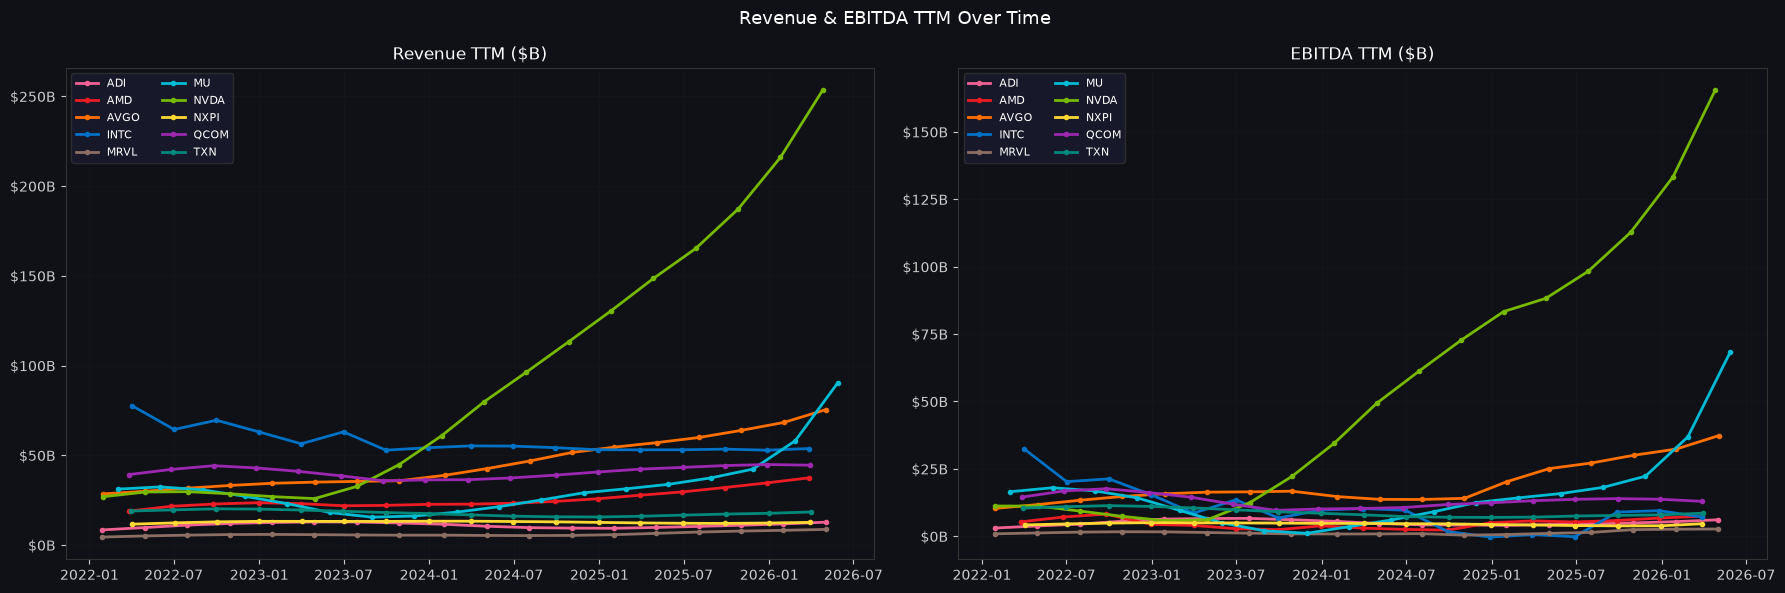

In [12]:
# Revenue TTM & EBITDA TTM
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Revenue & EBITDA TTM Over Time', fontsize=13)
for t in tickers:
    sub = df[df['ticker'] == t]
    axes[0].plot(sub['quarter_end'], sub['revenue_ttm']/1e9,
                 color=TICKER_COLORS[t], lw=2, marker='o', ms=3, label=t)
    axes[1].plot(sub['quarter_end'], sub['ebitda_ttm']/1e9,
                 color=TICKER_COLORS[t], lw=2, marker='o', ms=3, label=t)
axes[0].set_title('Revenue TTM ($B)'); axes[1].set_title('EBITDA TTM ($B)')
for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}B'))
    ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout()
save(fig, '07_revenue_ebitda_ttm')
plt.show()

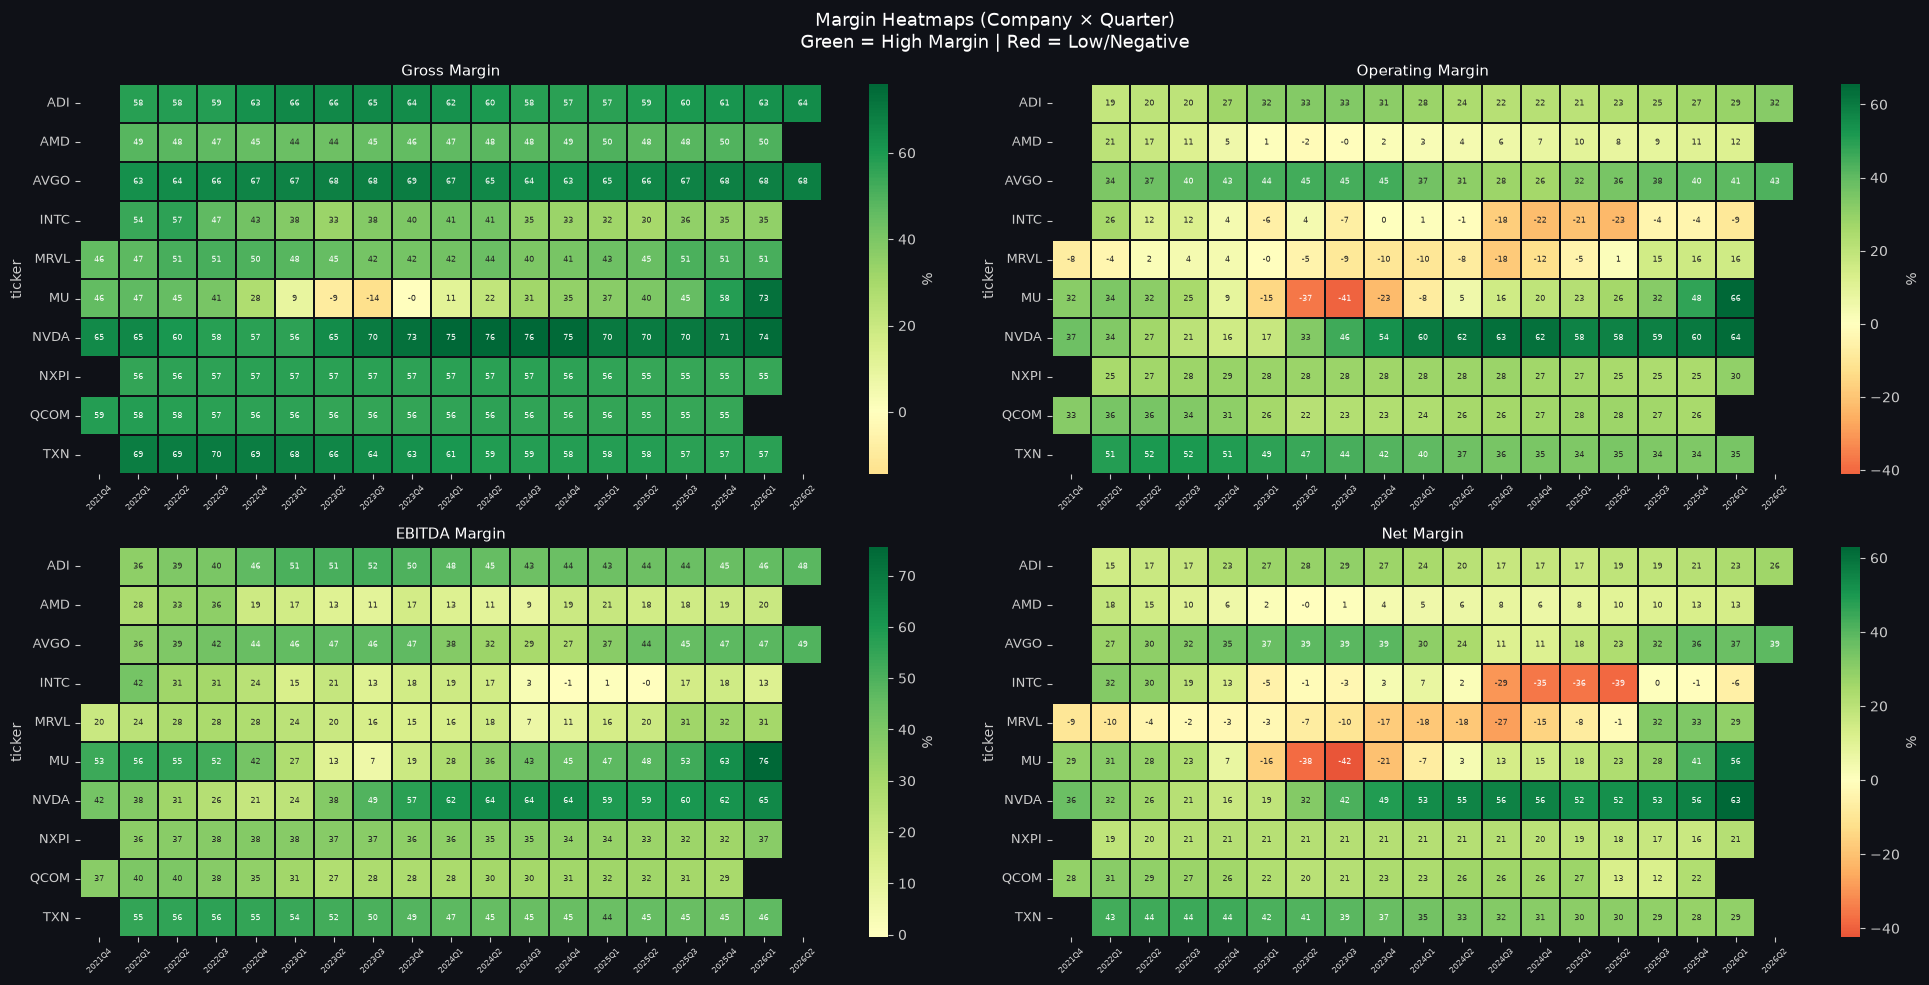

In [13]:
# Margin heatmaps (companies × quarters)
margin_cols = ['gross_margin', 'operating_margin', 'ebitda_margin', 'net_margin']
margin_labels = ['Gross Margin', 'Operating Margin', 'EBITDA Margin', 'Net Margin']

fig, axes = plt.subplots(2, 2, figsize=(20, 10))
fig.suptitle('Margin Heatmaps (Company × Quarter)\nGreen = High Margin | Red = Low/Negative', fontsize=13)

for ax, col, label in zip(axes.flat, margin_cols, margin_labels):
    pivot = df.pivot_table(index='ticker', columns='fiscal_quarter_label', values=col)
    # Sort columns chronologically
    pivot = pivot[sorted(pivot.columns)]
    sns.heatmap(
        pivot * 100,
        ax=ax,
        cmap='RdYlGn',
        center=0,
        annot=True, fmt='.0f', annot_kws={'size': 6},
        linewidths=0.3, linecolor='#0f1117',
        cbar_kws={'label': '%'}
    )
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
save(fig, '08_margin_heatmaps')
plt.show()

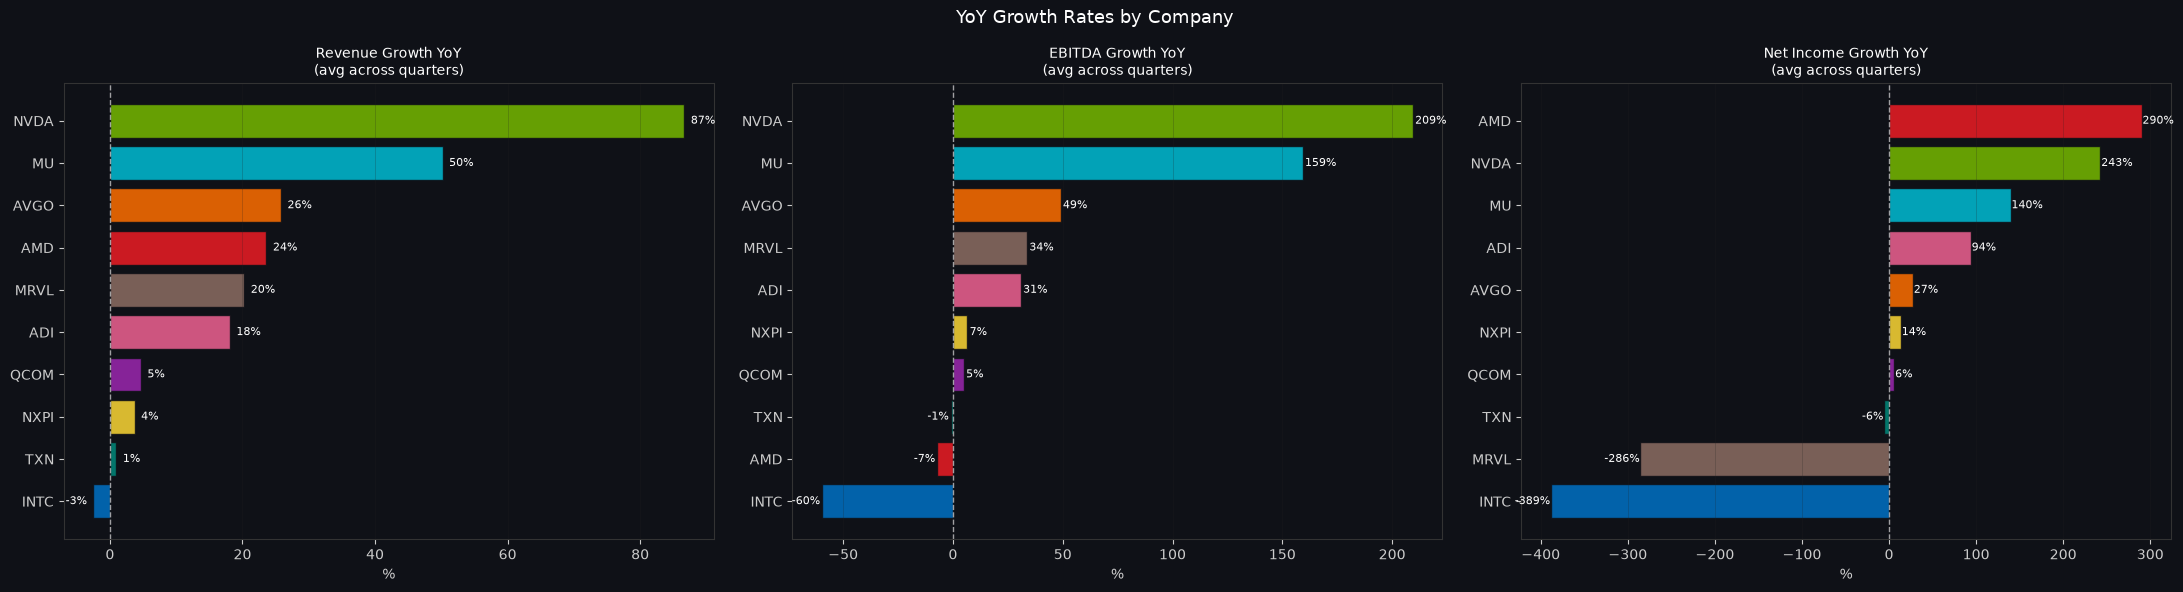

In [14]:
# YoY growth rates
growth_cols = [
    ('revenue_growth_yoy',    'Revenue Growth YoY'),
    ('ebitda_growth_yoy',     'EBITDA Growth YoY'),
    ('net_income_growth_yoy', 'Net Income Growth YoY')]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('YoY Growth Rates by Company', fontsize=13)

for ax, (col, label) in zip(axes, growth_cols):
    pivot = df.groupby('ticker')[col].mean().sort_values()
    colors = [TICKER_COLORS[t] for t in pivot.index]
    bars = ax.barh(pivot.index, pivot.values * 100, color=colors, edgecolor='#0f1117', alpha=0.85)
    ax.axvline(0, color='white', lw=1, ls='--', alpha=0.6)
    ax.set_title(f'{label}\n(avg across quarters)', fontsize=10)
    ax.set_xlabel('%')
    ax.grid(axis='x', alpha=0.3)
    # Annotate
    for bar, val in zip(bars, pivot.values * 100):
        ax.text(val + (1 if val >= 0 else -1), bar.get_y() + bar.get_height()/2,
                f'{val:.0f}%', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
save(fig, '09_yoy_growth_rates')
plt.show()

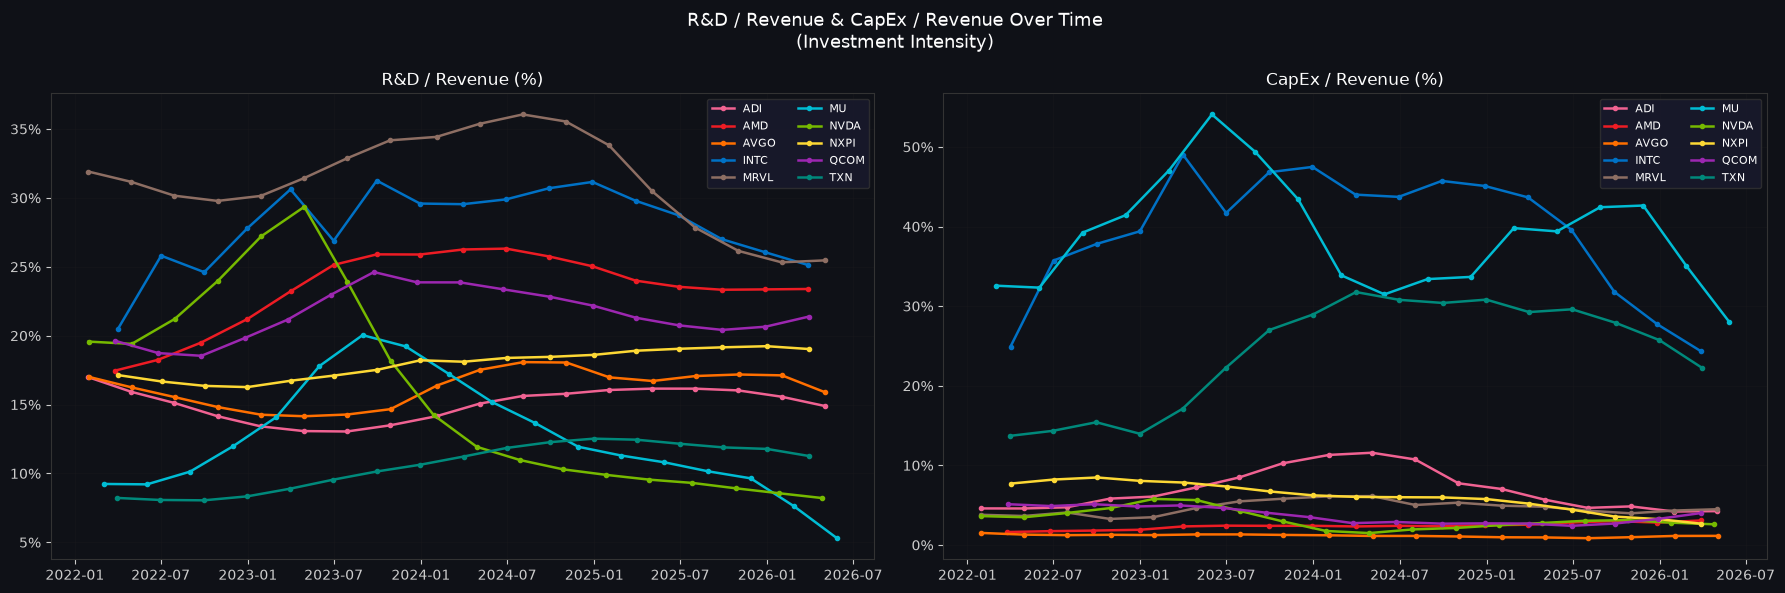

In [15]:
# R&D and CapEx intensity over time
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('R&D / Revenue & CapEx / Revenue Over Time\n(Investment Intensity)', fontsize=13)
for t in tickers:
    sub = df[df['ticker'] == t]
    axes[0].plot(sub['quarter_end'], sub['rd_to_revenue']*100,
                 color=TICKER_COLORS[t], lw=1.8, marker='o', ms=3, label=t)
    axes[1].plot(sub['quarter_end'], sub['capex_to_revenue']*100,
                 color=TICKER_COLORS[t], lw=1.8, marker='o', ms=3, label=t)
axes[0].set_title('R&D / Revenue (%)')
axes[1].set_title('CapEx / Revenue (%)')
for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
    ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout()
save(fig, '10_rd_capex_intensity')
plt.show()

The margin heatmap tells the clearest story: NVDA's gross margin expanded from 56% to 74% while INTC's collapsed from 57% to 30%, with net margin hitting -38.6% in loss quarters. This deterioration perfectly mirrors its market cap stagnation. 
NVDA, despite having only average R&D intensity at 16% of revenue, generated the highest revenue growth by far (avg +87% YoY), suggesting its AI tailwind is more about demand than R&D spend.

# 4. Market value vs financial value

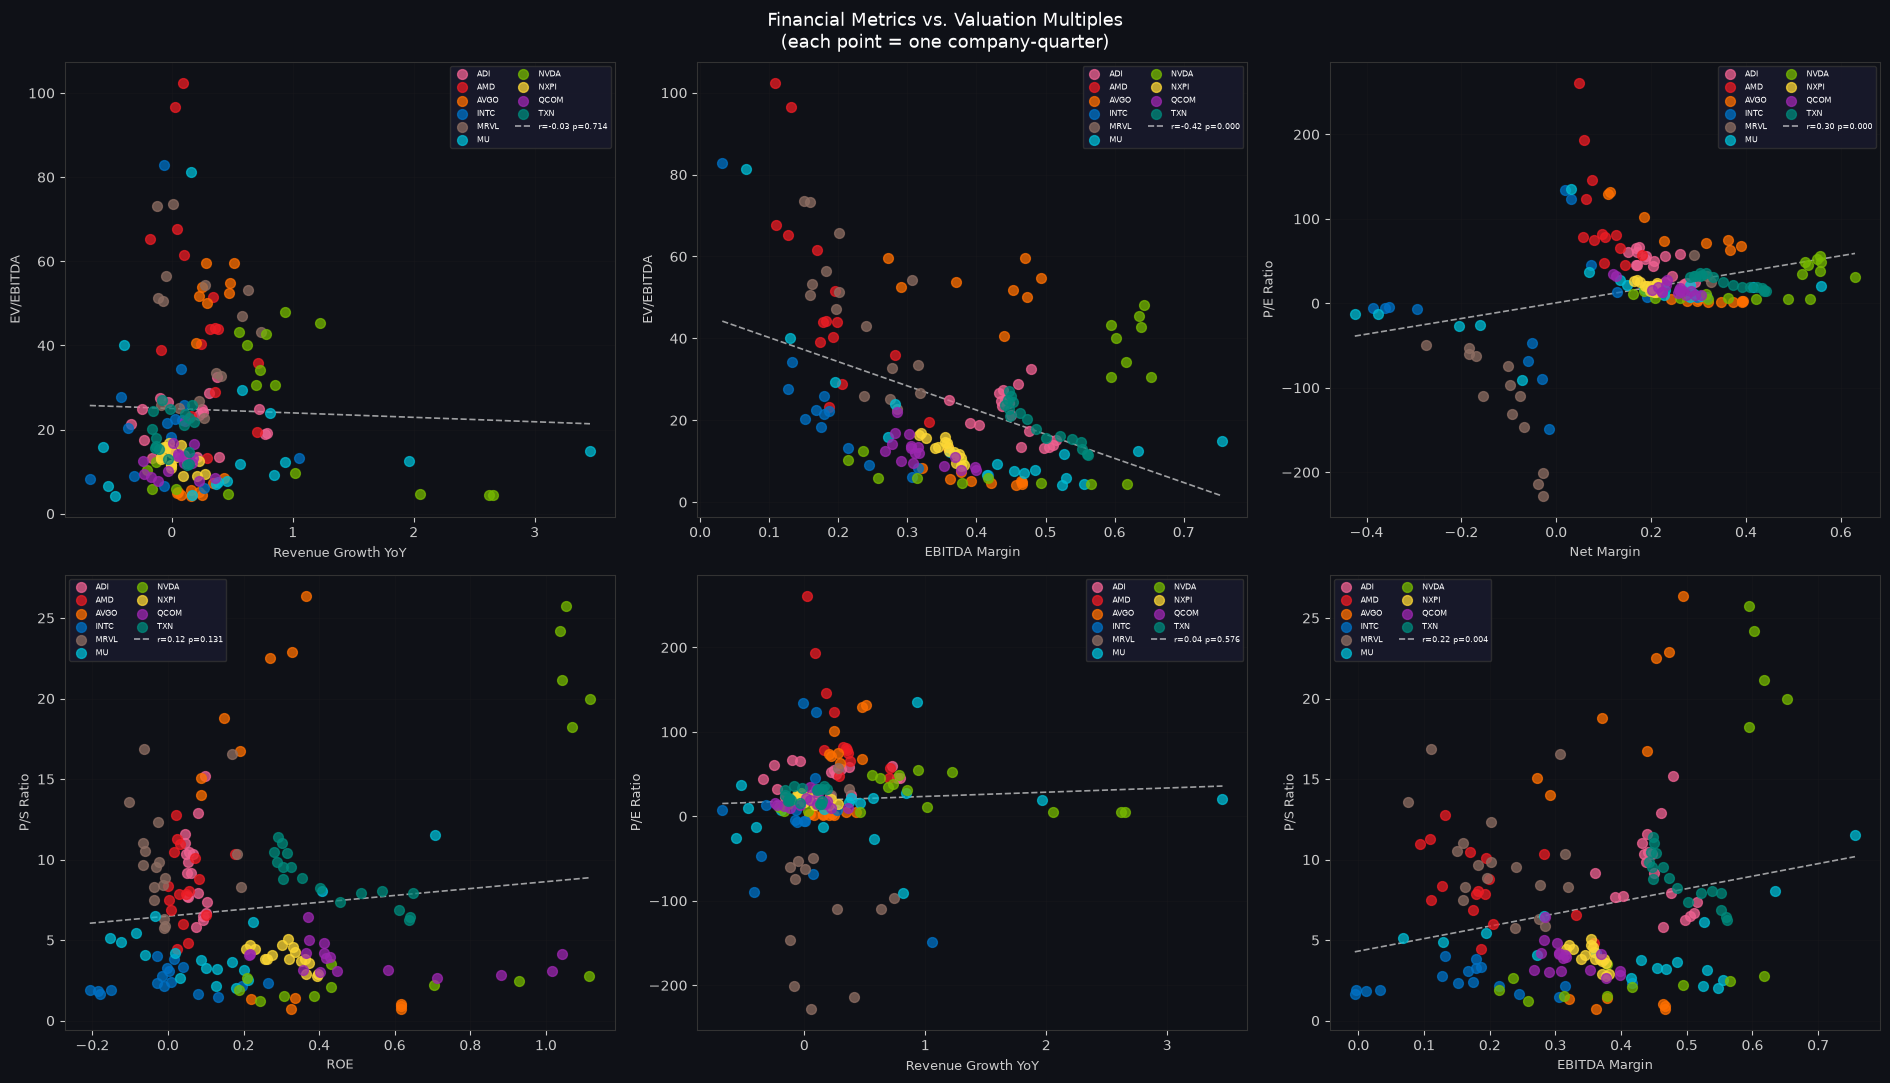

In [16]:
# Scatter: Financial metric vs Valuation multiple
scatter_pairs = [
    ('revenue_growth_yoy', 'ev_to_ebitda',   'Revenue Growth YoY', 'EV/EBITDA'),
    ('ebitda_margin',      'ev_to_ebitda',   'EBITDA Margin',      'EV/EBITDA'),
    ('net_margin',         'pe_ratio',        'Net Margin',         'P/E Ratio'),
    ('roe',                'price_to_sales',  'ROE',                'P/S Ratio'),
    ('revenue_growth_yoy', 'pe_ratio',        'Revenue Growth YoY', 'P/E Ratio'),
    ('ebitda_margin',      'price_to_sales',  'EBITDA Margin',      'P/S Ratio')]

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
fig.suptitle('Financial Metrics vs. Valuation Multiples\n(each point = one company-quarter)', fontsize=13)

for ax, (xcol, ycol, xlabel, ylabel) in zip(axes.flat, scatter_pairs):
    sub = df[[xcol, ycol, 'ticker']].dropna()
    # clip extreme outliers for readability
    q_low, q_high = sub[ycol].quantile(0.02), sub[ycol].quantile(0.98)
    sub = sub[(sub[ycol] >= q_low) & (sub[ycol] <= q_high)]
    for t in tickers:
        mask = sub['ticker'] == t
        ax.scatter(sub[mask][xcol], sub[mask][ycol],
                   color=TICKER_COLORS[t], s=50, alpha=0.75, label=t, zorder=3)
    try:
        m, b, r, p, _ = stats.linregress(sub[xcol], sub[ycol])
        xs = np.linspace(sub[xcol].min(), sub[xcol].max(), 100)
        ax.plot(xs, m*xs+b, color='white', lw=1.2, ls='--', alpha=0.6,
                label=f'r={r:.2f} p={p:.3f}')
    except Exception:
        pass
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=6, ncol=2)
    ax.grid(alpha=0.3)

plt.tight_layout()
save(fig, '11_scatter_fundamentals_vs_multiples')
plt.show()


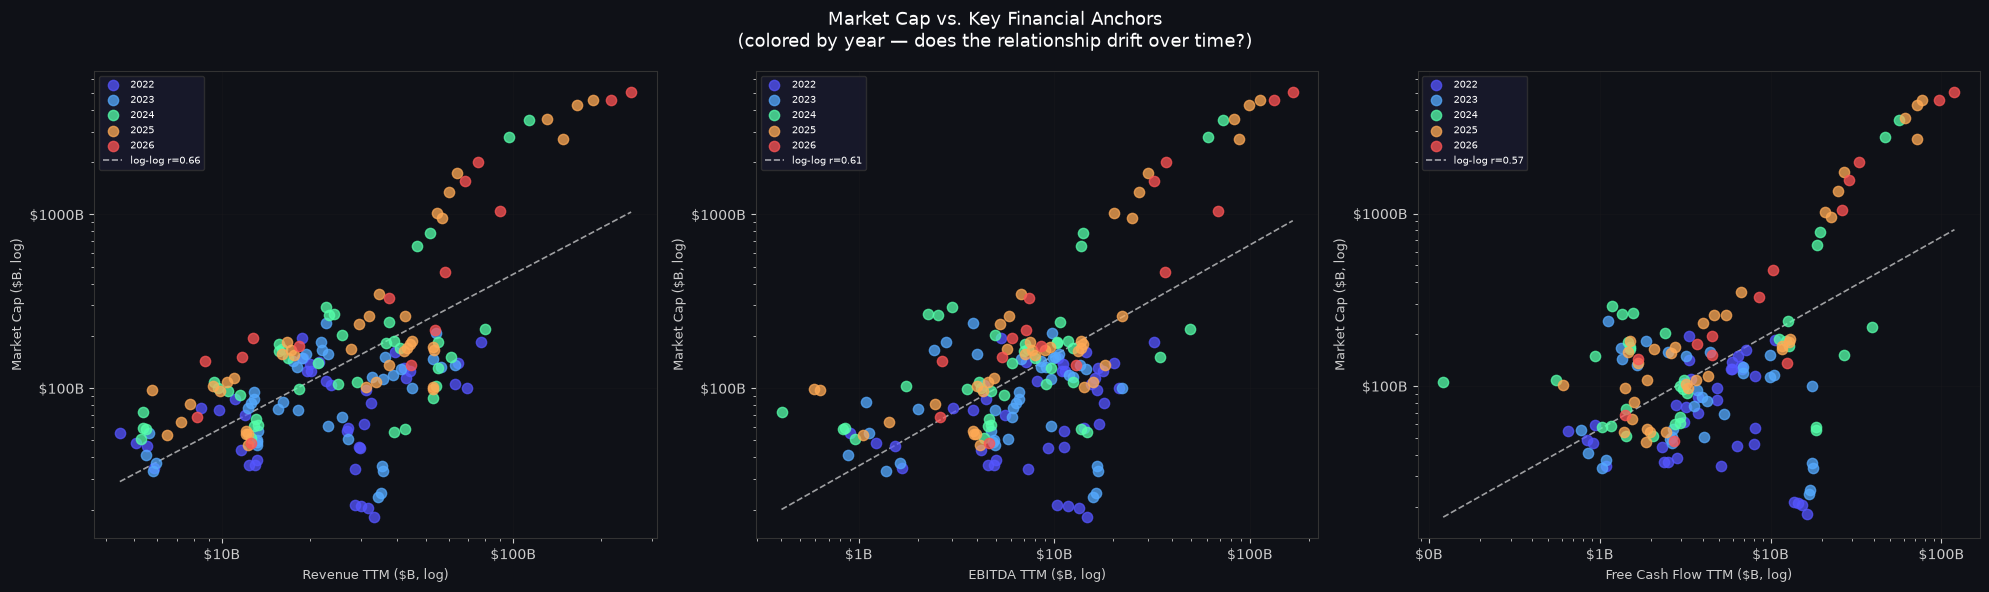

In [17]:
# Market Cap vs Revenue / EBITDA / FCF (colored by year)
year_palette = {2022:'#5555ff', 2023:'#55aaff', 2024:'#55ffaa', 2025:'#ffaa55', 2026:'#ff5555'}
df['year'] = df['quarter_end'].dt.year

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Market Cap vs. Key Financial Anchors\n(colored by year — does the relationship drift over time?)', fontsize=13)
fin_pairs = [
    ('revenue_ttm',       'Revenue TTM'),
    ('ebitda_ttm',        'EBITDA TTM'),
    ('free_cash_flow_ttm','Free Cash Flow TTM')]

for ax, (xcol, xlabel) in zip(axes, fin_pairs):
    sub = df[[xcol,'market_cap','year','ticker']].dropna()
    sub = sub[sub[xcol] > 0]
    for yr, grp in sub.groupby('year'):
        ax.scatter(grp[xcol]/1e9, grp['market_cap']/1e9,
                   color=year_palette.get(yr,'grey'), s=55, alpha=0.75, label=str(yr), zorder=3)
    try:
        m, b, r, p, _ = stats.linregress(np.log(sub[xcol]+1), np.log(sub['market_cap']+1))
        xs = np.linspace(sub[xcol].min(), sub[xcol].max(), 100)
        ys = np.exp(m * np.log(xs+1) + b)
        ax.plot(xs/1e9, ys/1e9, 'w--', lw=1.2, alpha=0.6, label=f'log-log r={r:.2f}')
    except Exception:
        pass
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}B'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}B'))
    ax.set_xlabel(f'{xlabel} ($B, log)', fontsize=9)
    ax.set_ylabel('Market Cap ($B, log)', fontsize=9)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.tight_layout()
save(fig, '12_market_cap_vs_financials')
plt.show()


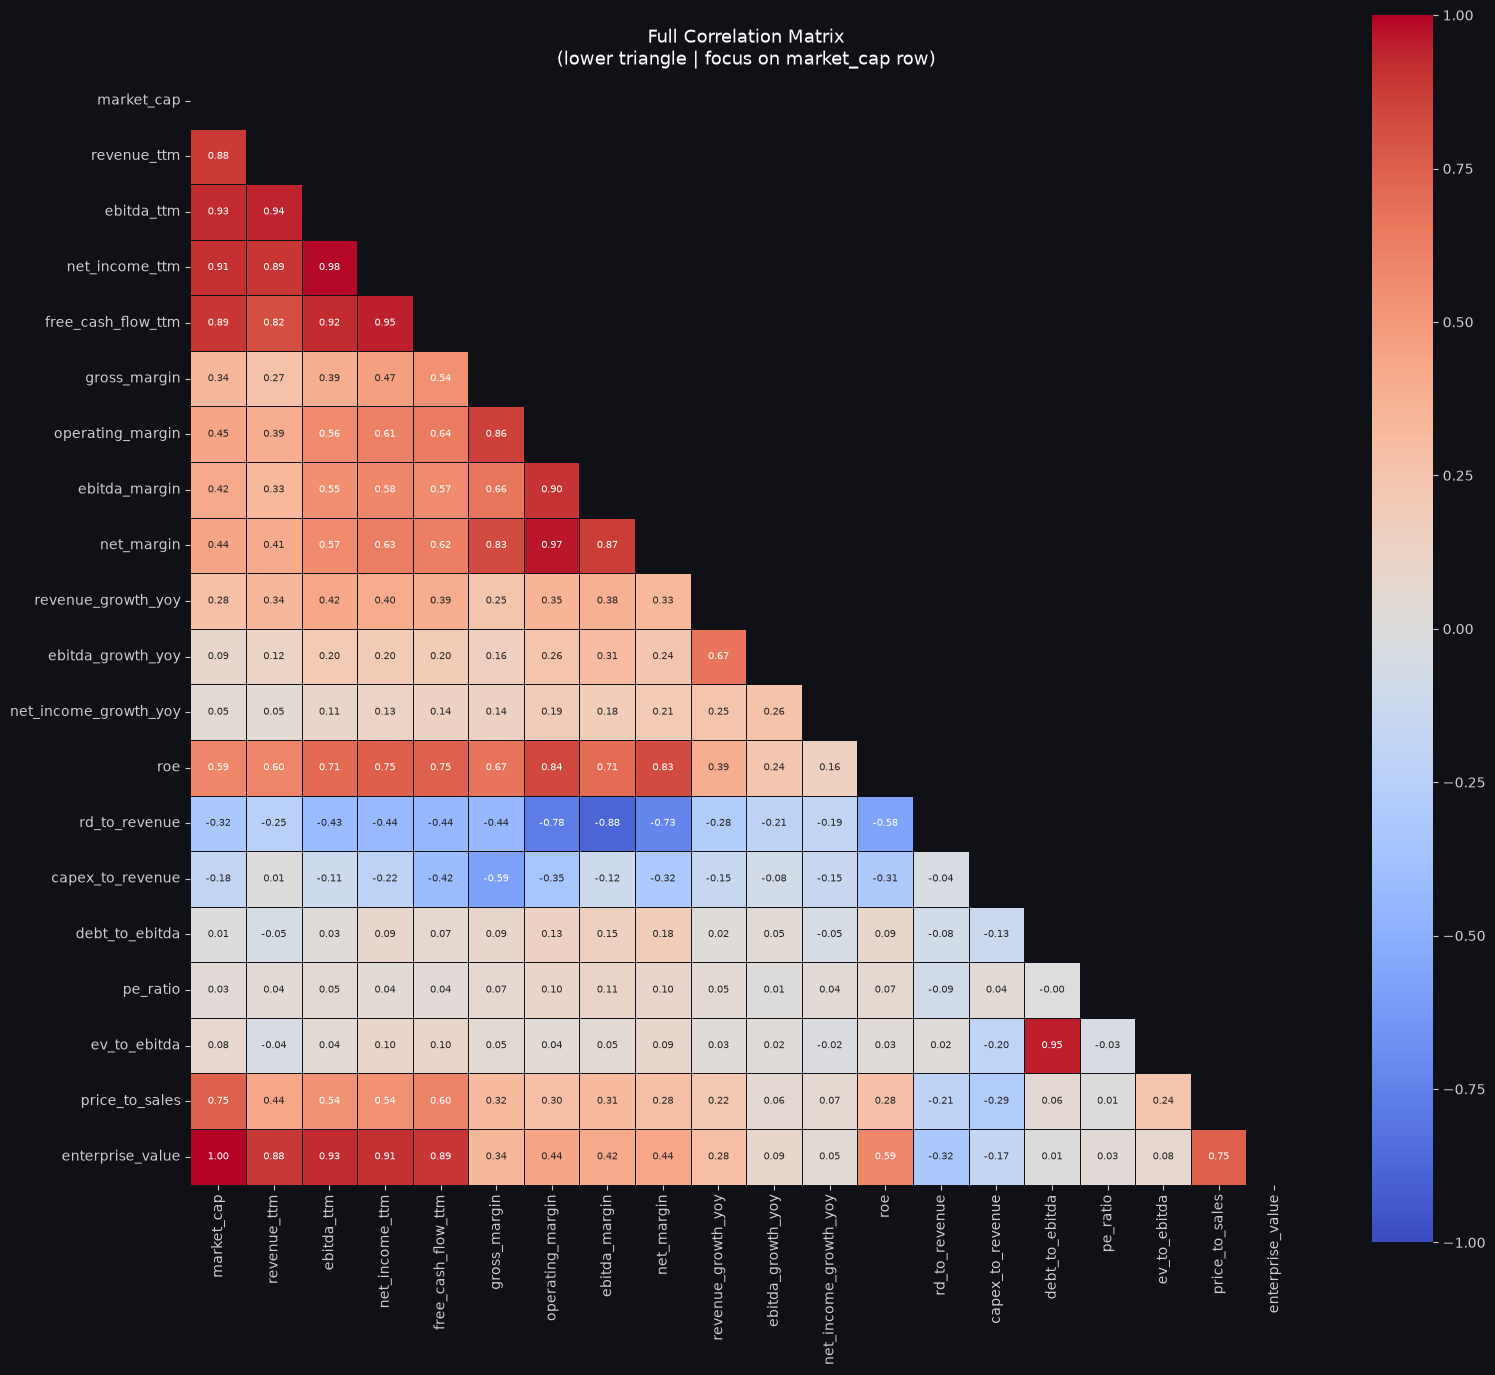

In [18]:
# Full correlation heatmap 
corr_cols = [
    'market_cap','revenue_ttm','ebitda_ttm','net_income_ttm','free_cash_flow_ttm',
    'gross_margin','operating_margin','ebitda_margin','net_margin',
    'revenue_growth_yoy','ebitda_growth_yoy','net_income_growth_yoy',
    'roe','rd_to_revenue','capex_to_revenue','debt_to_ebitda',
    'pe_ratio','ev_to_ebitda','price_to_sales','enterprise_value']

corr_matrix = df[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.4, linecolor='#0f1117',
    square=True)

ax.set_title('Full Correlation Matrix\n(lower triangle | focus on market_cap row)', fontsize=13)
plt.tight_layout()
save(fig, '13_correlation_heatmap')
plt.show()

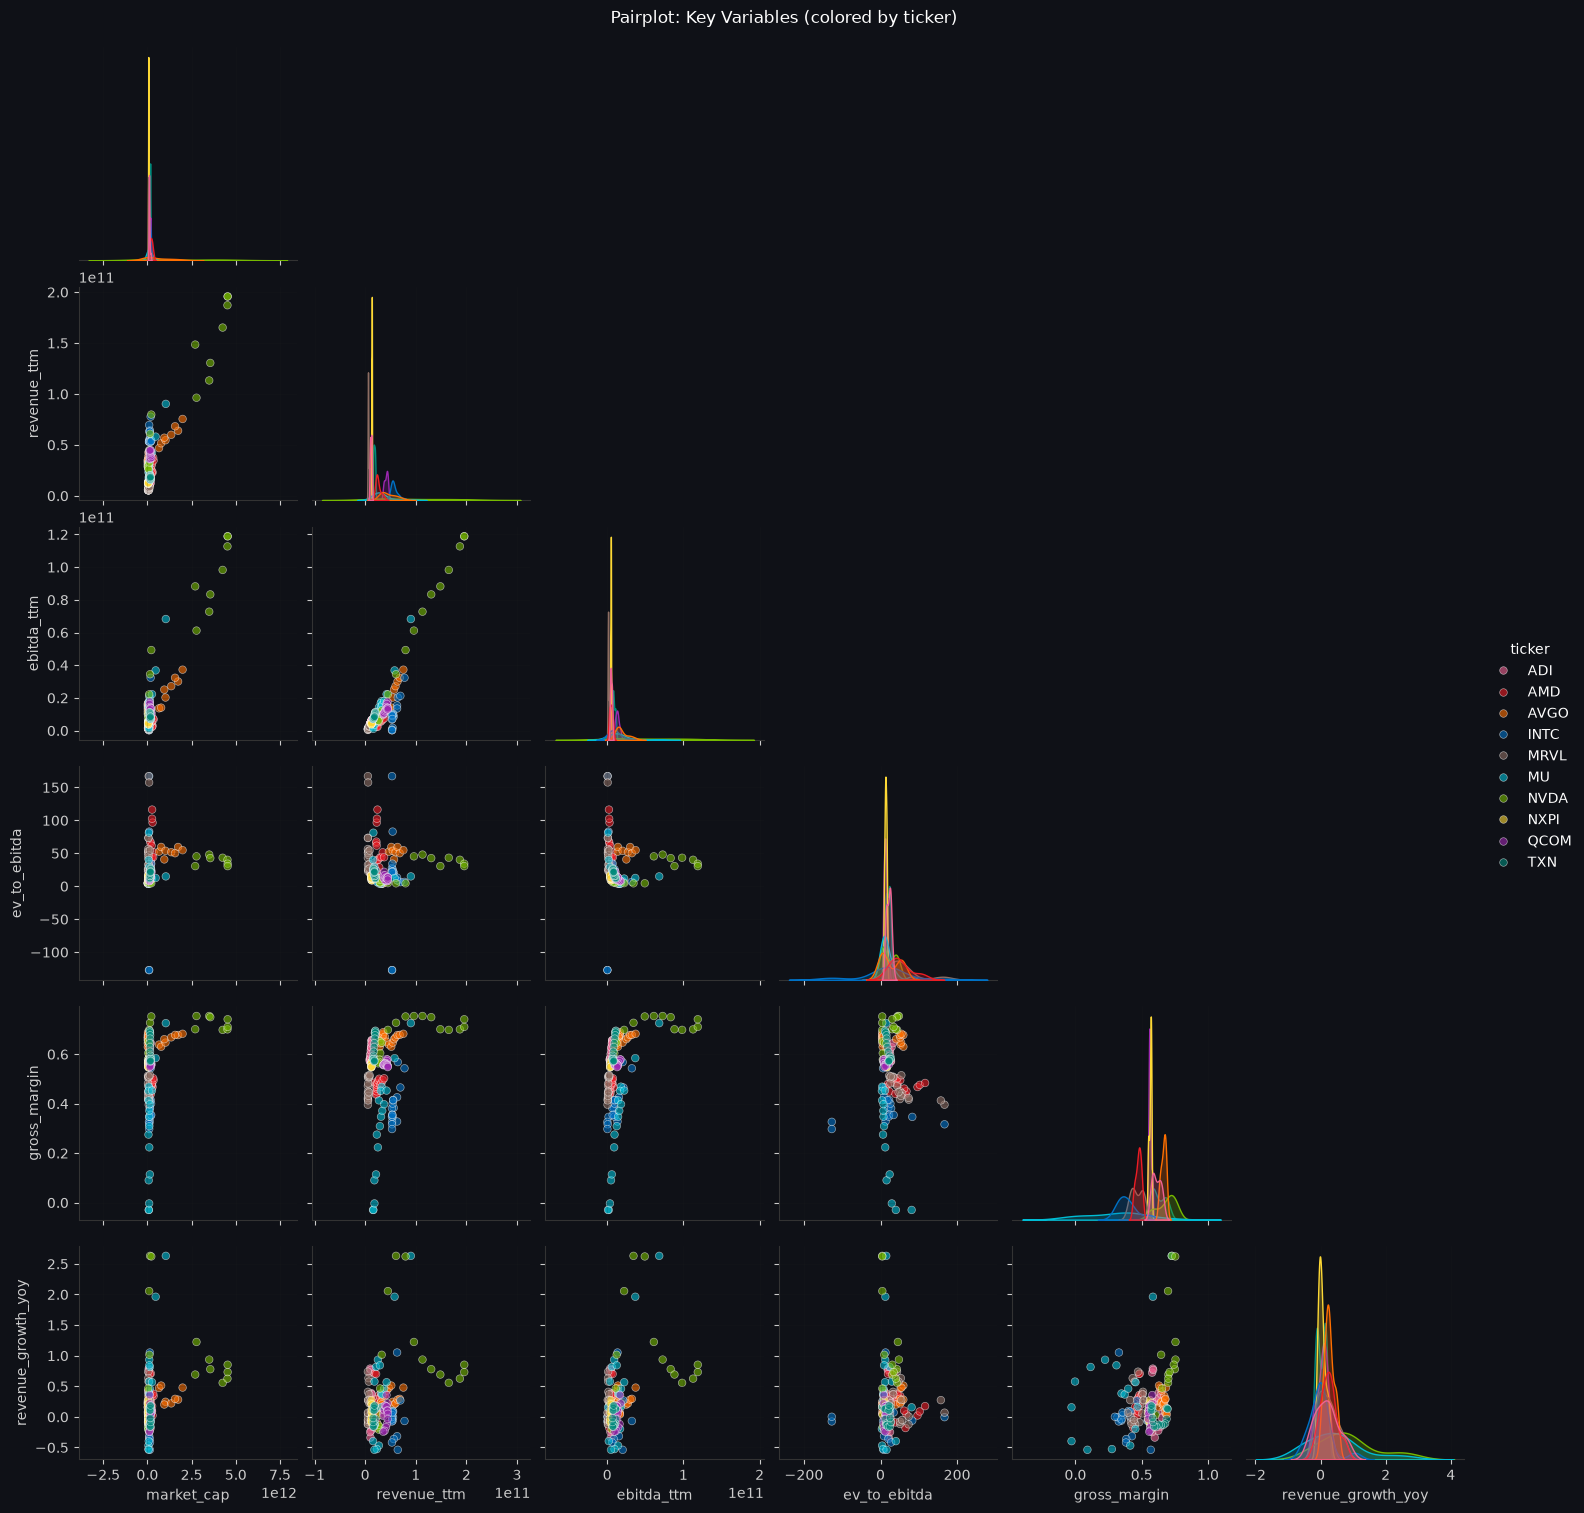

In [19]:
# Pairplot: 6 key variables
pair_cols = ['market_cap','revenue_ttm','ebitda_ttm','ev_to_ebitda','gross_margin','revenue_growth_yoy']
pair_df = df[pair_cols + ['ticker']].dropna()
# Clip extremes
for c in pair_cols:
    q1, q99 = pair_df[c].quantile(0.01), pair_df[c].quantile(0.99)
    pair_df[c] = pair_df[c].clip(q1, q99)

pg = sns.pairplot(
    pair_df, hue='ticker',
    palette=TICKER_COLORS,
    plot_kws={'alpha': 0.6, 's': 30},
    diag_kind='kde',
    corner=True)

pg.figure.suptitle('Pairplot: Key Variables (colored by ticker)', y=1.01, fontsize=12)
pg.figure.patch.set_facecolor('#0f1117')
for ax in pg.axes.flat:
    if ax:
        ax.set_facecolor('#0f1117')
        ax.grid(alpha=0.2)
save(fig, '14_pairplot')
plt.show()

The log-log relationship between market cap and revenue TTM is strong (Pearson r = 0.66), confirming that scale is a primary driver of valuation — but the year-colored scatter reveals that post-2024 points sit above the trend line, meaning the market rewarded AI-adjacent companies with valuation premiums well beyond what their revenues alone would predict. NVDA's P/S jumped from ~1.2x in late 2022 to ~31x in Q4 2024, while its revenue grew ~9x — the multiple expanded far faster than the fundamentals.

# 5. Company comparison

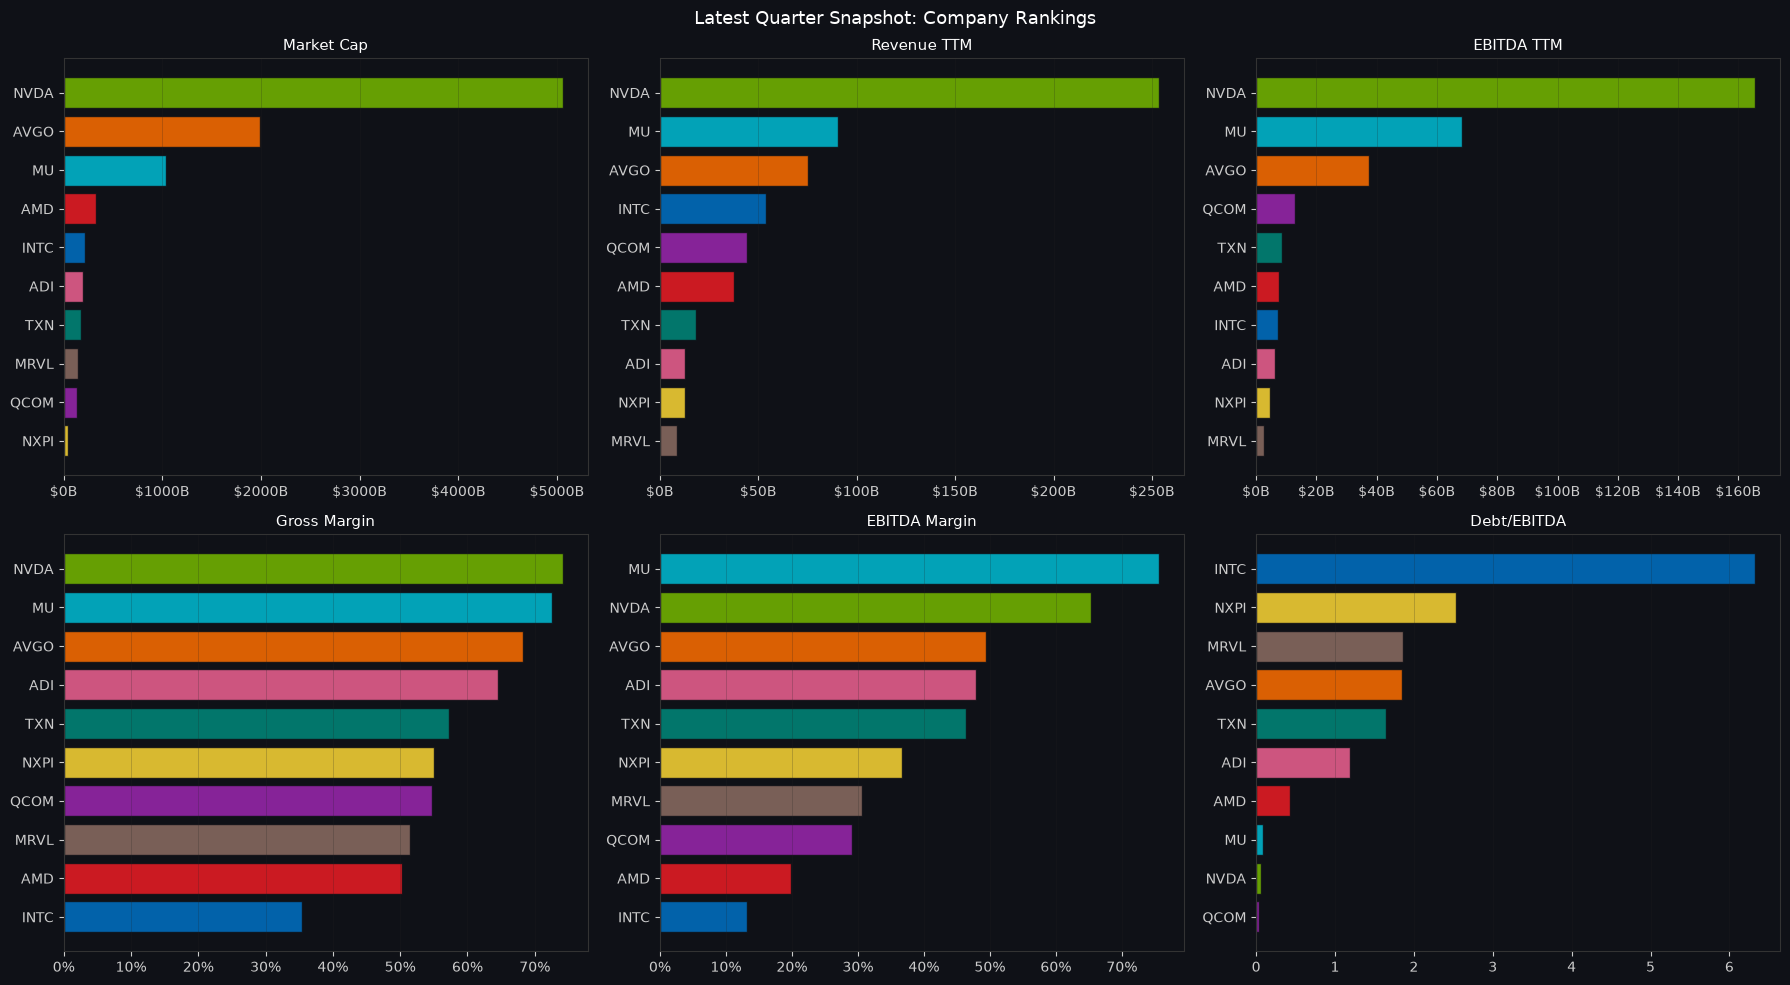

In [20]:
latest = df.sort_values('quarter_end').groupby('ticker').last().reset_index()

# Ranked bar charts
snapshot_metrics = [
    ('market_cap',     'Market Cap',     billions),
    ('revenue_ttm',    'Revenue TTM',    billions),
    ('ebitda_ttm',     'EBITDA TTM',     billions),
    ('gross_margin',   'Gross Margin',   lambda x,_: f'{x:.0%}'),
    ('ebitda_margin',  'EBITDA Margin',  lambda x,_: f'{x:.0%}'),
    ('debt_to_ebitda', 'Debt/EBITDA',    None),]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Latest Quarter Snapshot: Company Rankings', fontsize=13)

for ax, (col, label, fmt) in zip(axes.flat, snapshot_metrics):
    sub = latest[['ticker', col]].dropna().sort_values(col, ascending=True)
    colors = [TICKER_COLORS[t] for t in sub['ticker']]
    bars = ax.barh(sub['ticker'], sub[col], color=colors, edgecolor='#0f1117', alpha=0.85)
    ax.set_title(label, fontsize=11)
    if fmt:
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt))
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
save(fig, '15_snapshot_rankings')
plt.show()

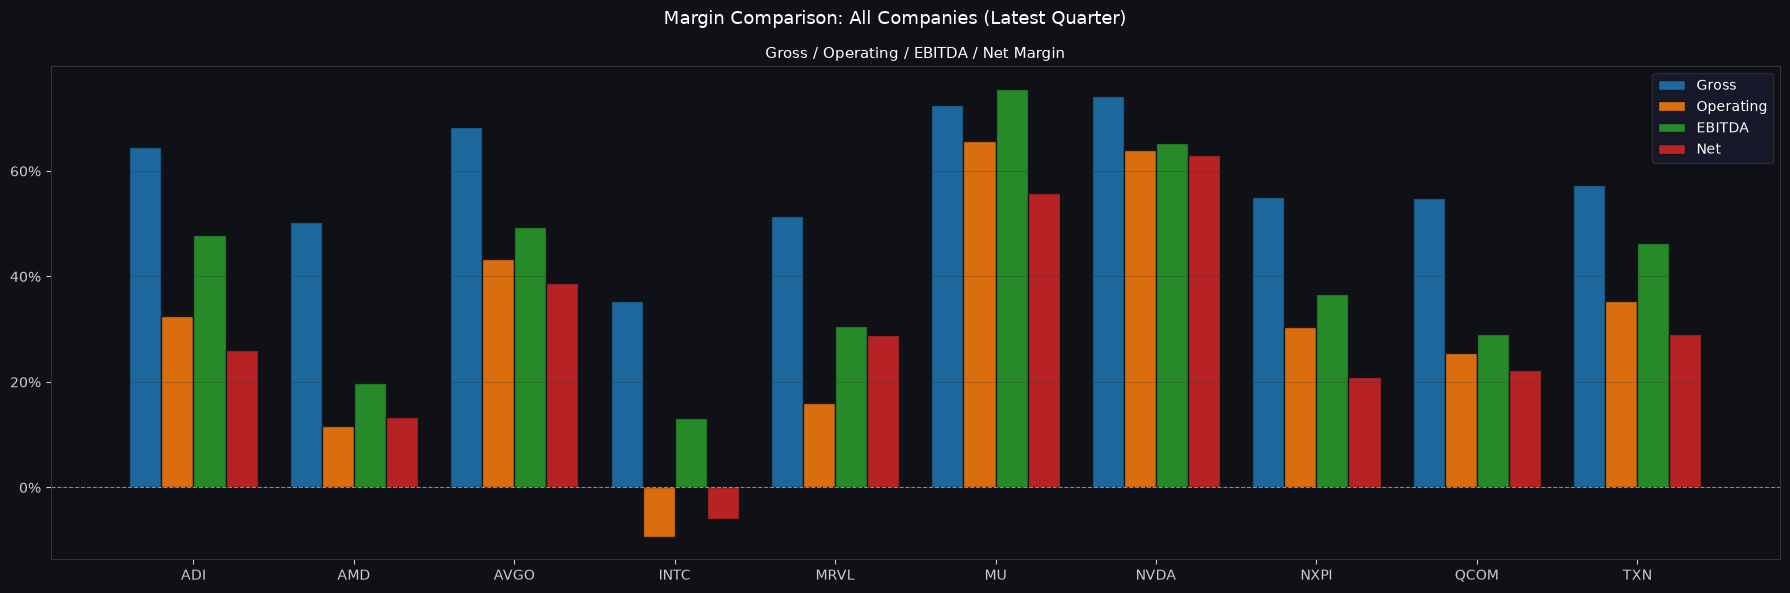

In [21]:
# Grouped margin comparison bar 

margin_order = ['gross_margin','operating_margin','ebitda_margin','net_margin']
margin_lbl   = ['Gross','Operating','EBITDA','Net']
x = np.arange(len(tickers))
w = 0.2
fig, ax = plt.subplots(figsize=(18, 6))
fig.suptitle('Margin Comparison: All Companies (Latest Quarter)', fontsize=13)
latest_sorted = latest.set_index('ticker').loc[tickers]

for i, (col, lbl) in enumerate(zip(margin_order, margin_lbl)):
    vals = latest_sorted[col].values * 100
    bars = ax.bar(x + i*w, vals, w, label=lbl, alpha=0.85, edgecolor='#0f1117')

ax.set_xticks(x + w*1.5)
ax.set_xticklabels(tickers, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'{y:.0f}%'))
ax.axhline(0, color='white', lw=0.8, ls='--', alpha=0.5)
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_title('Gross / Operating / EBITDA / Net Margin', fontsize=11)
plt.tight_layout()
save(fig, '16_margin_comparison')
plt.show()

There's a clear two-tier structure: NVDA, AVGO, and TXN lead on margin efficiency (EBITDA margins of 65%, 49%, 46%), while INTC, AMD, and MRVL are high-spend, lower-margin businesses. Notably, MRVL and AMD rank highest on average EV/EBITDA (60x and 53x respectively) despite not being the most profitable — the market is pricing in future growth expectations, not current earnings.

# 6. Hypothesis testing

In [22]:
# NORMALITY CHECK ON MARKET CAP

# Before choosing Pearson or Spearman, we must check if market_cap is normallydistributed. This is the same workflow as the housing dataset in the bootcamp:
# histogram -> Q-Q plot -> KS test.
 
print("IS MARKET CAP NORMALLY DISTRIBUTED?")
print("H0: market_cap follows a normal distribution")
print("H1: market_cap does NOT follow a normal distribution")

 
mc = df['market_cap'].dropna()

IS MARKET CAP NORMALLY DISTRIBUTED?
H0: market_cap follows a normal distribution
H1: market_cap does NOT follow a normal distribution


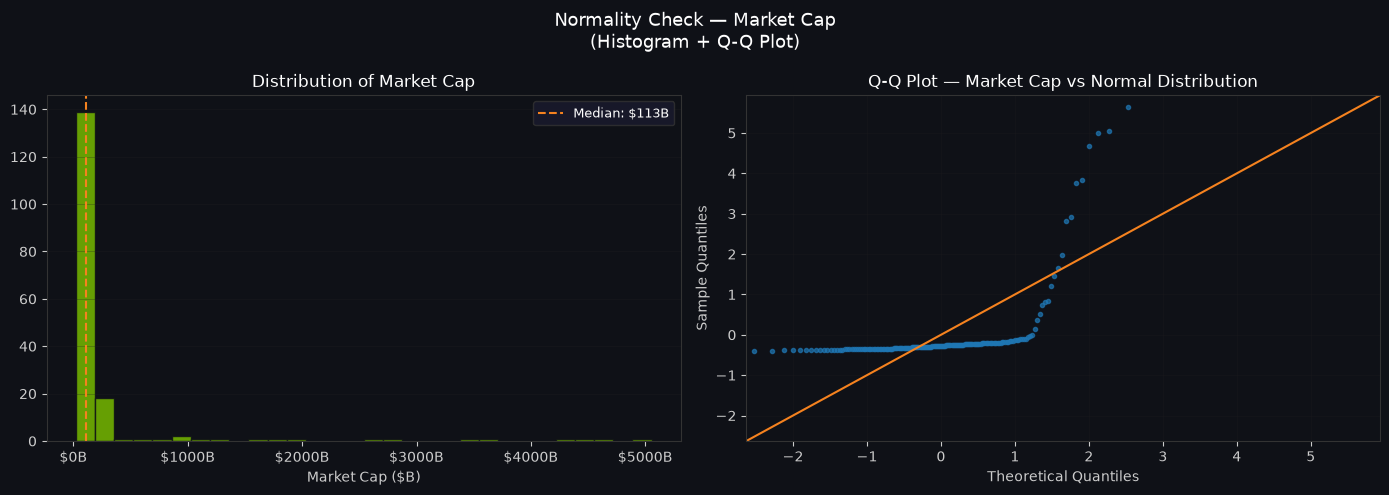

In [23]:
# visual check for normal distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Normality Check — Market Cap\n(Histogram + Q-Q Plot)', fontsize=13)

#histogram
axes[0].hist(mc / 1e9, bins=30, color='#76b900', edgecolor='#0f1117', alpha=0.85)
axes[0].set_title('Distribution of Market Cap')
axes[0].set_xlabel('Market Cap ($B)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
axes[0].axvline(mc.median() / 1e9, color='#f5821f', lw=1.5, ls='--',
                label=f'Median: ${mc.median()/1e9:.0f}B')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.4)
axes[0].set_facecolor('#0f1117')

# Q-Q plot 
sm.qqplot(mc.values, fit=True, line='45', ax=axes[1])
axes[1].set_title('Q-Q Plot — Market Cap vs Normal Distribution')
axes[1].get_lines()[0].set(color='#76b900', markersize=3, alpha=0.7)   # data points
axes[1].get_lines()[1].set(color='#f5821f', lw=1.5)                    # 45° line
axes[1].set_facecolor('#0f1117')
axes[1].grid(alpha=0.3)
 
plt.tight_layout()
save(fig, '16_normality_check_histogram_qq')
plt.show()
 

In [24]:
# KS test 
#standardize then test against standard normal
alpha=0.05
mc_standardized = (mc - mc.mean()) / mc.std()
ks_stat, ks_p = stats.kstest(mc_standardized, 'norm')
 
print(f"Kolmogorov-Smirnov Test:")
print(f"  KS statistic : {ks_stat:.4f}")
print(f"  p-value      : {ks_p:.6f}")
 
if ks_p < alpha:
    print(f"  -> p={ks_p:.4f} < α={alpha}  ->  REJECT H0")
    print("  -> Market cap is NOT normally distributed -> use Spearman correlation")
    use_spearman = True
else:
    print(f"  -> p={ks_p:.4f} ≥ α={alpha}  ->  FAIL TO REJECT H0")
    print("  -> Market cap is normally distributed -> Pearson is appropriate")
    use_spearman = False

Kolmogorov-Smirnov Test:
  KS statistic : 0.4178
  p-value      : 0.000000
  -> p=0.0000 < α=0.05  ->  REJECT H0
  -> Market cap is NOT normally distributed -> use Spearman correlation


LOG TRANSFORMATION OF MARKET CAP


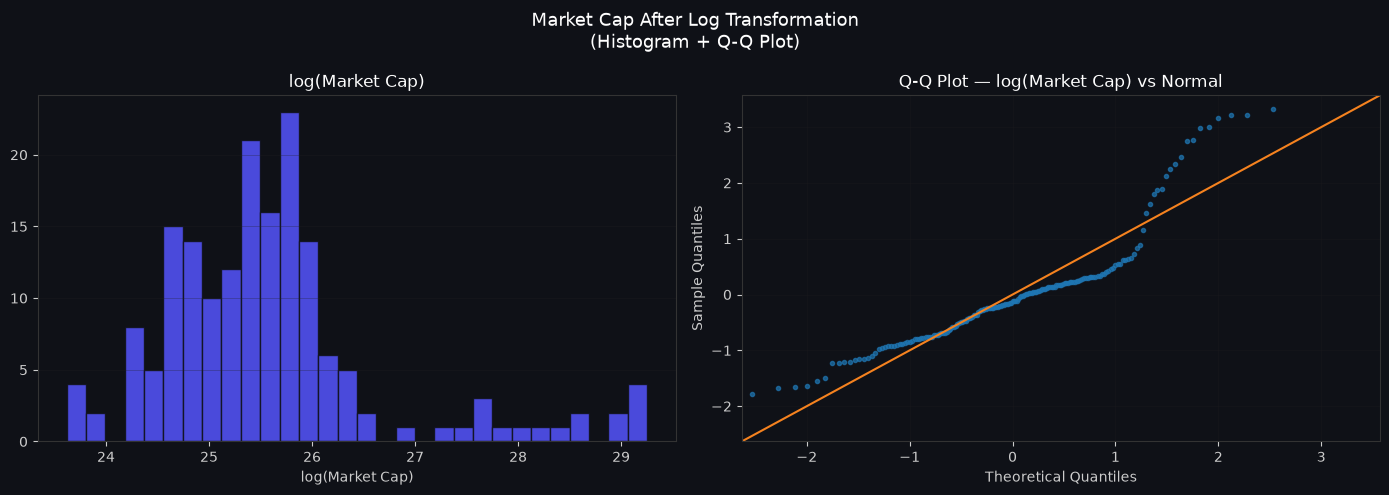


KS test after log transformation:
  KS statistic : 0.1753  (was 0.4178)
  p-value      : 0.0000     (was 0.000000)
  -> Points sit closer to the 45° line in Q-Q plot = more normal
  -> This is why we will log-transform market_cap before ML modeling


In [25]:
# LOG TRANSFORMATION
# because market cap is right-skewed (NVDA effect) apply log transformation

print("LOG TRANSFORMATION OF MARKET CAP")
 
log_mc = np.log(mc)
log_mc_std = (log_mc - log_mc.mean()) / log_mc.std()
 
# re-check normality after transformation
ks_stat_log, ks_p_log = stats.kstest(log_mc_std, 'norm')
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Market Cap After Log Transformation\n(Histogram + Q-Q Plot)', fontsize=13)
 
axes[0].hist(log_mc, bins=30, color='#5555ff', edgecolor='#0f1117', alpha=0.85)
axes[0].set_title('log(Market Cap)')
axes[0].set_xlabel('log(Market Cap)')
axes[0].grid(axis='y', alpha=0.4)
axes[0].set_facecolor('#0f1117')
 
sm.qqplot(log_mc.values, fit=True, line='45', ax=axes[1])
axes[1].set_title('Q-Q Plot — log(Market Cap) vs Normal')
axes[1].get_lines()[0].set(color='#5555ff', markersize=3, alpha=0.7)
axes[1].get_lines()[1].set(color='#f5821f', lw=1.5)
axes[1].set_facecolor('#0f1117')
axes[1].grid(alpha=0.3)
 
plt.tight_layout()
save(fig, '17_log_transform_normality')
plt.show()
 
print(f"\nKS test after log transformation:")
print(f"  KS statistic : {ks_stat_log:.4f}  (was {ks_stat:.4f})")
print(f"  p-value      : {ks_p_log:.4f}     (was {ks_p:.6f})")
print("  -> Points sit closer to the 45° line in Q-Q plot = more normal")
print("  -> This is why we will log-transform market_cap before ML modeling")

In [26]:
#PEARSON CORRELATION 
# H0: no linear relationship between financial metric and market cap
# H1: there IS a significant linear relationship
# use Pearson on the log-transformed market cap (closer to normal)
 
print("PEARSON CORRELATION: Financial Metrics vs Market Cap")
print("H0: correlation = 0 (no relationship)")
print("H1: correlation ≠ 0 (significant relationship exists)")
print(f"Significance level α = {alpha}")
 
test_cols = [
    ('revenue_ttm',        'Revenue TTM'),
    ('ebitda_ttm',         'EBITDA TTM'),
    ('net_income_ttm',     'Net Income TTM'),
    ('free_cash_flow_ttm', 'Free Cash Flow TTM'),
    ('gross_margin',       'Gross Margin'),
    ('ebitda_margin',      'EBITDA Margin'),
    ('operating_margin',   'Operating Margin'),
    ('revenue_growth_yoy', 'Revenue Growth YoY'),
    ('roe',                'ROE'),
    ('rd_to_revenue',      'R&D / Revenue'),
    ('capex_to_revenue',   'CapEx / Revenue'),
    ('debt_to_ebitda',     'Debt / EBITDA')]
 
results = []
for col, label in test_cols:
    sub = df[['market_cap', col]].dropna()
    if len(sub) < 10:
        continue
    r, p = stats.pearsonr(sub['market_cap'], sub[col])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    conclusion = 'REJECT H0 ✓' if p < alpha else 'fail to reject H0'
    results.append({
        'Feature':label,
        'Pearson r':round(r, 3),
        'p-value':round(p, 4),
        'Significance':sig,
        'Decision':conclusion,})
 
results_df = pd.DataFrame(results).sort_values('Pearson r', key=abs, ascending=False)
print("Pearson Correlation with Market Cap")
print(results_df.to_string(index=False))

PEARSON CORRELATION: Financial Metrics vs Market Cap
H0: correlation = 0 (no relationship)
H1: correlation ≠ 0 (significant relationship exists)
Significance level α = 0.05
Pearson Correlation with Market Cap
           Feature  Pearson r  p-value Significance          Decision
        EBITDA TTM      0.926   0.0000          ***       REJECT H0 ✓
    Net Income TTM      0.910   0.0000          ***       REJECT H0 ✓
Free Cash Flow TTM      0.894   0.0000          ***       REJECT H0 ✓
       Revenue TTM      0.880   0.0000          ***       REJECT H0 ✓
               ROE      0.574   0.0000          ***       REJECT H0 ✓
  Operating Margin      0.441   0.0000          ***       REJECT H0 ✓
     EBITDA Margin      0.415   0.0000          ***       REJECT H0 ✓
      Gross Margin      0.338   0.0000          ***       REJECT H0 ✓
     R&D / Revenue     -0.321   0.0000          ***       REJECT H0 ✓
Revenue Growth YoY      0.285   0.0002          ***       REJECT H0 ✓
   CapEx / Revenue   

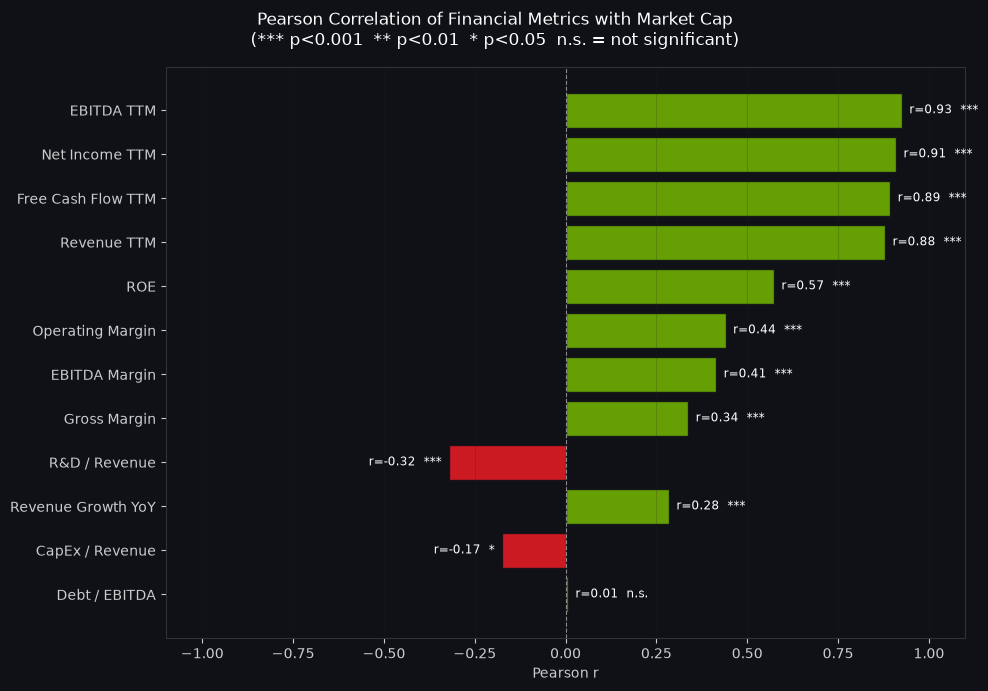

In [27]:
# VISUALISE CORRELATION RESULTS
 
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Pearson Correlation of Financial Metrics with Market Cap\n(*** p<0.001  ** p<0.01  * p<0.05  n.s. = not significant)',
             fontsize=12)
 
sub_plot = results_df.sort_values('Pearson r', ascending=True, key=abs)
colors = ['#76b900' if v > 0 else '#ed1c24' for v in sub_plot['Pearson r']]
bars = ax.barh(sub_plot['Feature'], sub_plot['Pearson r'],
               color=colors, edgecolor='#0f1117', alpha=0.85)
 
for bar, (_, row) in zip(bars, sub_plot.iterrows()):
    offset = 0.02 if row['Pearson r'] >= 0 else -0.02
    ha = 'left' if row['Pearson r'] >= 0 else 'right'
    ax.text(row['Pearson r'] + offset,
            bar.get_y() + bar.get_height() / 2,
            f"r={row['Pearson r']:.2f}  {row['Significance']}",
            va='center', ha=ha, fontsize=8.5, color='white')
 
ax.axvline(0, color='white', lw=0.8, ls='--', alpha=0.5)
ax.set_xlim(-1.1, 1.1)
ax.set_xlabel('Pearson r', fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
save(fig, '18_pearson_correlation_bar')
plt.show()

EBITDA TTM is the strongest financial predictor of market cap followed by Net Income TTM and FCF TTMmeaning we can reject H0 for all core financial metrics, confirming that the market and financial value are indeed significantly related, though the relationship isn't perfectly linear.

In [28]:
# TWO-SAMPLE T-TEST: AI companies vs Non-AI companies
#  do AI-adjacent companies (NVDA, AMD, AVGO, MU) have a significantlyhigher market cap than non-AI companies in the same period?
 
print("TWO-SAMPLE T-TEST")
print("H0: mean market cap is THE SAME for AI vs non-AI companies")
print("H1: AI companies have HIGHER mean market cap (one-tailed, 'greater')")
print(f"Significance level α = {alpha}")
 
ai_tickers     = ['NVDA', 'AMD', 'AVGO', 'MU']
non_ai_tickers = ['INTC', 'TXN', 'QCOM', 'ADI', 'NXPI', 'MRVL']
 
# filter from 2023 present when AI demand became relevant
ai_mask    = df['ticker'].isin(ai_tickers)    & (df['quarter_end'] >= '2023-01-01')
non_ai_mask = df['ticker'].isin(non_ai_tickers) & (df['quarter_end'] >= '2023-01-01')
 
mc_ai     = df[ai_mask]['market_cap'].dropna()
mc_non_ai = df[non_ai_mask]['market_cap'].dropna()
 
print(f"\n  AI companies     — n={len(mc_ai)},  mean=${mc_ai.mean()/1e9:.0f}B,  median=${mc_ai.median()/1e9:.0f}B")
print(f"  Non-AI companies — n={len(mc_non_ai)}, mean=${mc_non_ai.mean()/1e9:.0f}B,  median=${mc_non_ai.median()/1e9:.0f}B")
 
# ttest_ind with equal_var=False (Welch's)
t_stat, p_val = stats.ttest_ind(mc_ai, mc_non_ai, equal_var=False, alternative='greater')
 
print(f"\n  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_val:.6f}")
 
if p_val < alpha:
    print(f" p={p_val:.4f} < α={alpha}  -> REJECT H0")
   
else:
    print(f"  p={p_val:.4f} ≥ α={alpha}  ->  FAIL TO REJECT H0")
 

TWO-SAMPLE T-TEST
H0: mean market cap is THE SAME for AI vs non-AI companies
H1: AI companies have HIGHER mean market cap (one-tailed, 'greater')
Significance level α = 0.05

  AI companies     — n=55,  mean=$871B,  median=$219B
  Non-AI companies — n=80, mean=$115B,  median=$109B

  t-statistic : 4.1190
  p-value     : 0.000066
 p=0.0001 < α=0.05  -> REJECT H0


AI-adjacent companies have a statistically significantly higher market cap than non-AI companies since 2023. The AI boom createda measurable split in the semiconductor sector.

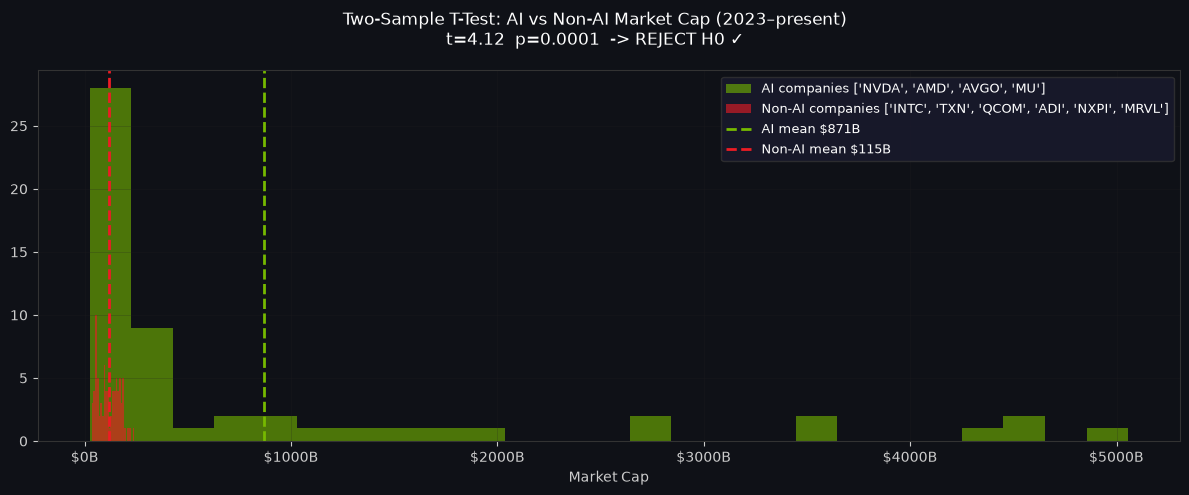

In [29]:
# visualize the two distributions

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle(
    f'Two-Sample T-Test: AI vs Non-AI Market Cap (2023–present)\n'
    f't={t_stat:.2f}  p={p_val:.4f}  -> {"REJECT H0 ✓" if p_val < alpha else "fail to reject H0"}',
    fontsize=12)
 
ax.hist(mc_ai / 1e9,     bins=25, alpha=0.6, color='#76b900', label=f'AI companies {ai_tickers}')
ax.hist(mc_non_ai / 1e9, bins=25, alpha=0.6, color='#ed1c24', label=f'Non-AI companies {non_ai_tickers}')
ax.axvline(mc_ai.mean() / 1e9,     color='#76b900', lw=2, ls='--', label=f'AI mean ${mc_ai.mean()/1e9:.0f}B')
ax.axvline(mc_non_ai.mean() / 1e9, color='#ed1c24', lw=2, ls='--', label=f'Non-AI mean ${mc_non_ai.mean()/1e9:.0f}B')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax.set_xlabel('Market Cap')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
save(fig, '19_ttest_ai_vs_nonai')
plt.show()

# 7. ML prep

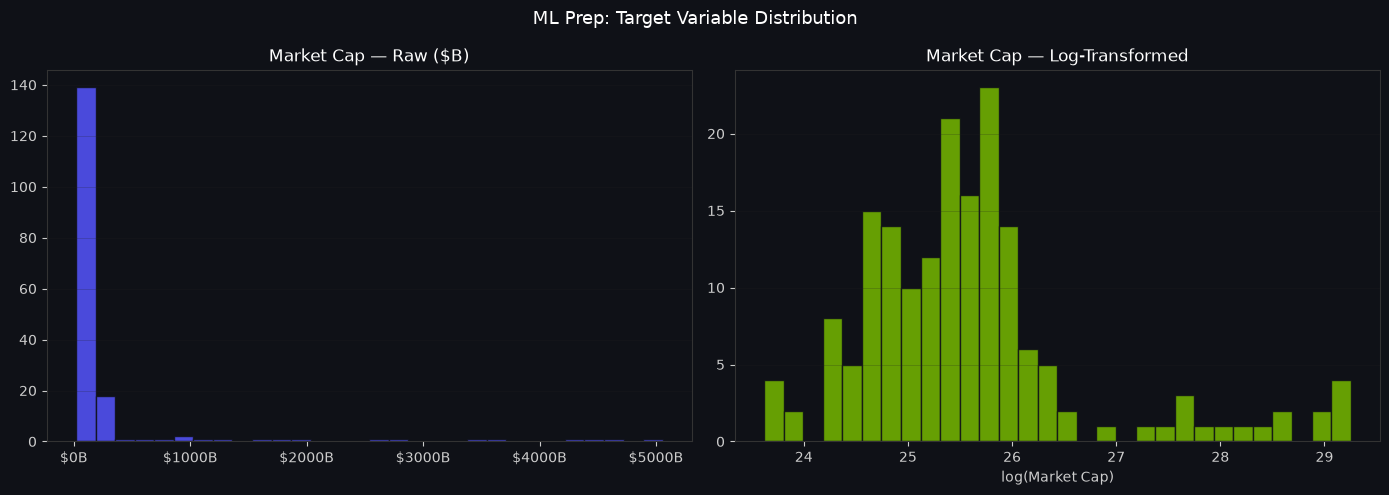

In [30]:
#target variable: market_cap distribution and log transform (log-transform confirmed necessary by KS normality test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ML Prep: Target Variable Distribution', fontsize=13)

mc = df['market_cap'].dropna()
axes[0].hist(mc/1e9, bins=30, color='#5555ff', edgecolor='#0f1117', alpha=0.85)
axes[0].set_title('Market Cap — Raw ($B)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}B'))

axes[1].hist(np.log(mc), bins=30, color='#76b900', edgecolor='#0f1117', alpha=0.85)
axes[1].set_title('Market Cap — Log-Transformed')
axes[1].set_xlabel('log(Market Cap)')

for ax in axes:
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save(fig, '20_target_distribution')
plt.show()

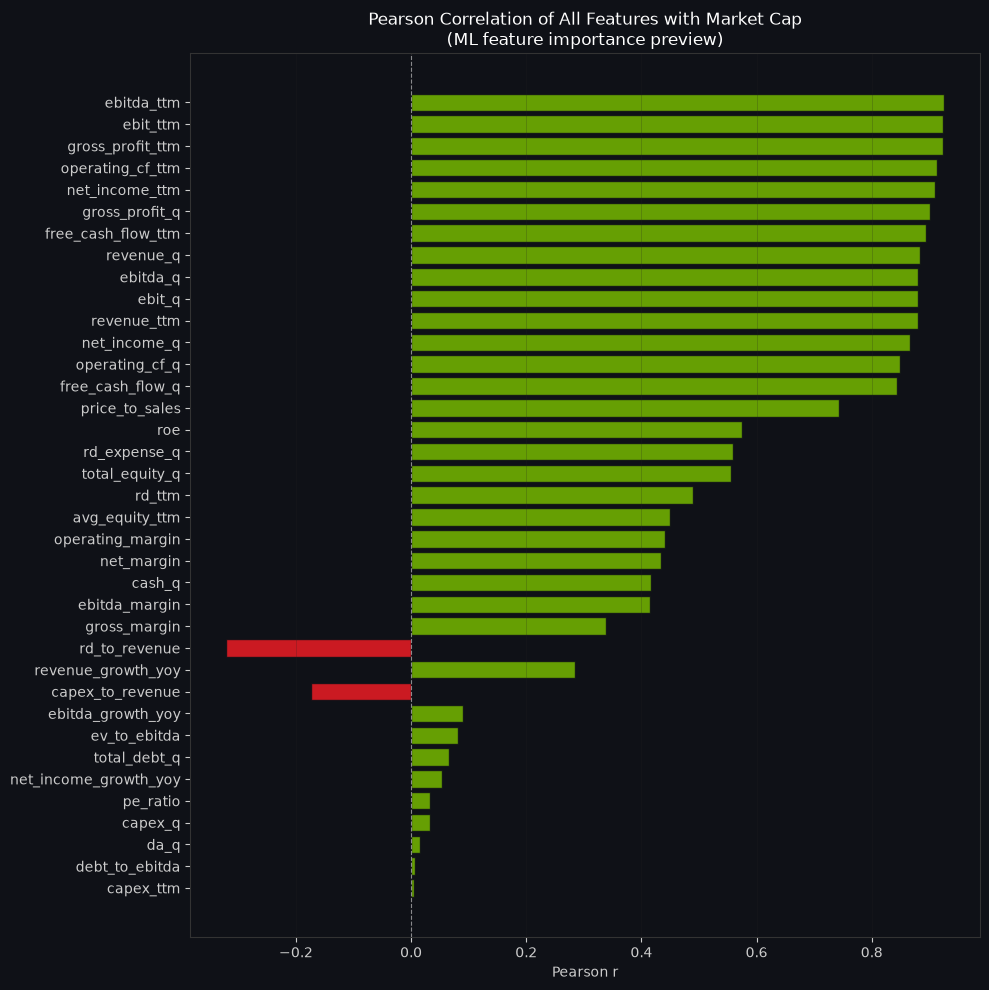

TOP FEATURES BY CORRELATION WITH MARKET CAP
ebitda_ttm            0.926
ebit_ttm              0.924
gross_profit_ttm      0.923
operating_cf_ttm      0.914
net_income_ttm        0.910
gross_profit_q        0.902
free_cash_flow_ttm    0.894
revenue_q             0.884
ebitda_q              0.881
ebit_q                0.881

EDA complete. All plots saved to /data/graphs


In [31]:
# feature correlation with target (ranked bar)

from scipy.stats import pearsonr

# feature correlation with target (ranked bar)
feature_cols = [c for c in df.select_dtypes(include='number').columns
                if c not in ['market_cap','shares_outstanding','close_price',
                             'enterprise_value','year']]

corr_with_target = {}
for col in feature_cols:
    sub = df[['market_cap', col]].dropna()
    if len(sub) > 10:
        r, p = pearsonr(sub['market_cap'], sub[col])
        corr_with_target[col] = r

corr_series = pd.Series(corr_with_target).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#76b900' if v > 0 else '#ed1c24' for v in corr_series.values]
ax.barh(corr_series.index[::-1], corr_series.values[::-1],
        color=colors[::-1], edgecolor='#0f1117', alpha=0.85)
ax.axvline(0, color='white', lw=0.8, ls='--', alpha=0.5)  
ax.set_title('Pearson Correlation of All Features with Market Cap\n(ML feature importance preview)', fontsize=12)
ax.set_xlabel('Pearson r')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
save(fig, '21_feature_importance_preview')
plt.show()

print("TOP FEATURES BY CORRELATION WITH MARKET CAP")
print(corr_series.head(10).round(3).to_string())
print("\nEDA complete. All plots saved to /data/graphs")